In [1]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import os, glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep
from skimage.measure import block_reduce
from numpy.lib.stride_tricks import as_strided
plt.style.use([hep.style.ROOT, hep.style.firamath])
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LogNorm, ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)
from numpy.lib.stride_tricks import as_strided




mkdir -p failed for path /uscms_data/d1/bbbam/.cache/matplotlib: [Errno 30] Read-only file system: '/uscms_data'
Matplotlib created a temporary cache directory at /tmp/matplotlib-ysc9ex07 because there was an issue with the default path (/uscms_data/d1/bbbam/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# out_dir='data/plot_H_AA_4Tau_M_10_signal_kinematics'
out_dir='../analysis_run3/AN_Note_Plot/Images_miniAOD'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)
save = False

In [2]:
def upsample_array(x, b0, b1):
    r, c = x.shape                                    # number of rows/columns
    rs, cs = x.strides                                # row/column strides
    x = as_strided(x, (r, b0, c, b1), (rs, 0, cs, 0)) # view as a larger 4D array
    return x.reshape(r*b0, c*b1)/(b0*b1) # create new 2D array with same total occupancy
    


def crop_jet(imgECAL, iphi, ieta, jet_shape=125):

    # NOTE: jet_shape here should correspond to the one used in RHAnalyzer
    off = jet_shape//2
    iphi = int(iphi*5 + 2) # 5 EB xtals per HB tower
    ieta = int(ieta*5 + 2) # 5 EB xtals per HB tower

    # Wrap-around on left side
    if iphi < off:
        diff = off-iphi
        img_crop = np.concatenate((imgECAL[:,ieta-off:ieta+off+1,-diff:],
                                   imgECAL[:,ieta-off:ieta+off+1,:iphi+off+1]), axis=-1)
    # Wrap-around on right side
    elif 360-iphi < off:
        diff = off - (360-iphi)
        img_crop = np.concatenate((imgECAL[:,ieta-off:ieta+off+1,iphi-off:],
                                   imgECAL[:,ieta-off:ieta+off+1,:diff+1]), axis=-1)
    # Nominal case
    else:
        img_crop = imgECAL[:,ieta-off:ieta+off+1,iphi-off:iphi+off+1]

    return img_crop

### Layesrs in images

In [3]:
layers =['TracksAtECAL_pt', 'TracAtECAL_dZSig', 'TracAtECAL_d0Sig', 'ECAL_energy', \
         'HBHE_energy']
print("Number of layers", len(layers))


Number of layers 5


### Plotting function

In [4]:
def plotJet_single_layer(img, eve, run):
    img[np.abs(img) < 1.e-3] = 0 # to rmove noise
    mins = [0.00001]*len(img)
    maxs =[]
    for j in range(len(img)):
         maxs.append(img[j].max())
    # out_dir='plot_for_prelim'
    # if not os.path.isdir(out_dir):
    #     os.makedirs(out_dir)
    for k in range(len(img)):
        fig, ax = plt.subplots(dpi=300)
        color = ['Oranges','Blues','Greys','Greens', 'Blues']
        if k<5:
            color_selected = color[k]
        else:
            color_selected = color[2]
            
        if maxs[k]  > 0 : plt.imshow(img[k], cmap=f'{color_selected}', norm=LogNorm(vmin=mins[k], vmax=maxs[k]),  alpha=0.9)
        # plt.title(f"{layers[k]}")
        hep.cms.label(llabel=f"Simulation  " +layers[k] , rlabel="13.6 TeV", loc=0, ax=ax)
        plt.xlabel(r"$i\varphi$") #28, 30
        plt.ylabel(r"$i\eta$") #28, 30

        # plt.savefig(f'{out_dir}/single_layer_image_event_{eve}_{layers[k]}.pdf',facecolor='w',dpi=300)
        plt.show()
    return img 


def plotJet(img, eve, dr):
    mins = [0.001]*len(img)
    maxs =[]
    for i in range(len(img)):
        maxs.append(img[i].max())
    fig, ax = plt.subplots(figsize=(12,10),dpi=300)
    if maxs[0]  > 0 : plt.imshow(img[0], cmap='Oranges', norm=LogNorm(vmin=mins[0], vmax=maxs[0]),  alpha=0.9)
    if maxs[1]  > 0 : plt.imshow(img[1], cmap='Blues',   norm=LogNorm(vmin=mins[1], vmax=maxs[1]),  alpha=0.9)
    if maxs[2]  > 0 : plt.imshow(img[2], cmap='Greys',   norm=LogNorm(vmin=mins[2], vmax=maxs[2]),  alpha=0.9)
    if maxs[3]  > 0 : plt.imshow(img[3], cmap='Greens',  norm=LogNorm(vmin=mins[3], vmax=maxs[3]),  alpha=0.9)       
    if maxs[4]  > 0 : plt.imshow(img[4], cmap='Blues',   norm=LogNorm(vmin=mins[4], vmax=maxs[4]),  alpha=0.4)   
    # if maxs[5]  > 0 : plt.imshow(img[5], cmap='Purples', norm=LogNorm(vmin=mins[5], vmax=maxs[5]),  alpha=0.9)   
    # if maxs[10] > 0 : plt.imshow(img[10], cmap= 'pink',  norm=LogNorm(vmin=mins[10],vmax=maxs[10]), alpha=0.9)
    hep.cms.label(llabel=r"Simulation     $\Delta R_{\tau\tau}$"+f"={dr:.3f}", rlabel=f"13.6 TeV", loc=0, ax=ax)
    plt.xlabel(r"$i\varphi$") #28, 30
    plt.ylabel(r"$i\eta$") #28, 30
    #LEGEND
    colors = {0:'orange',1:'blue',2:'grey',3:'green',4:'lightblue'}
    labels = {0:'Track pT',1:'dz_sig',2:'d0_sig',3:'ECAL',4:'HCAL'}
    patches =[mpatches.Patch(color=colors[i],label=labels[i]) for i in colors]
    plt.legend(handles=patches, bbox_to_anchor=(1.005, 1), loc=2, borderaxespad=0.)
    plt.tight_layout()
    dr = np.round(dr,3)
    dr_str = str(dr).replace('.', 'p')
    # plt.savefig(f"{out_dir}/combined_image_event_{eve}_dr_{dr_str}.pdf",facecolor='w',dpi=300,)
    plt.show()

### Plot cropped images function

In [5]:

def make_img_eve_cropped(i):
    ECAL_energy = np.array(branches["ECAL_energy_miniAOD"][i]).reshape(280,360)
    HBHE_energy_ = np.array(branches["HBHE_energy_miniAOD"][i]).reshape(56,72)
    HBHE_energy = upsample_array(HBHE_energy_, 5, 5) # (280, 360)
    TracksAtECAL_pt = np.array(branches["ECAL_tracksPt_atECALfixIP"][i]).reshape(280,360)
    TracksAtECAL_dZSig = np.array(branches["ECAL_tracksDzSig_atECALfixIP"][i]).reshape(280,360)
    TracksAtECAL_d0Sig = np.array(branches["ECAL_tracksD0Sig_atECALfixIP"][i]).reshape(280,360)
    
    X_CMS             = np.stack([TracksAtECAL_pt, TracksAtECAL_dZSig, TracksAtECAL_d0Sig, ECAL_energy, HBHE_energy], axis=0) # (5, 280, 360)
    # ys = ak.Array(branches["jetIsSignal"])[i]
    ys = ak.Array(branches["jetIsDiTau"])[i]
    iphis  = ak.Array(branches["jetSeed_iphi"])[i]
    ietas  = ak.Array(branches["jetSeed_ieta"])[i]
    dR = ak.Array(branches["TaudR"])[i]
    print("Event Number:", i)
    for j in range(len(ys)):
        img_cropped = crop_jet(X_CMS, iphis[j], ietas[j], jet_shape=125)
        plotJet(img_cropped, i, dR[j])
        break
        
def make_img_all_layers_cropped(i, run):
    ECAL_energy = np.array(branches["ECAL_energy_miniAOD"][i]).reshape(280,360)
    HBHE_energy_ = np.array(branches["HBHE_energy_miniAOD"][i]).reshape(56,72)
    HBHE_energy = upsample_array(HBHE_energy_, 5, 5) # (280, 360)
    TracksAtECAL_pt = np.array(branches["ECAL_tracksPt_atECALfixIP"][i]).reshape(280,360)
    TracksAtECAL_dZSig = np.array(branches["ECAL_tracksDzSig_atECALfixIP"][i]).reshape(280,360)
    TracksAtECAL_d0Sig = np.array(branches["ECAL_tracksD0Sig_atECALfixIP"][i]).reshape(280,360)
    X_CMS             = np.stack([TracksAtECAL_pt, TracksAtECAL_dZSig, TracksAtECAL_d0Sig, ECAL_energy, HBHE_energy, PixAtEcal_1], axis=0) # (5, 280, 360)
    # ys = ak.Array(branches["jetIsSignal"])[i]
    ys = ak.Array(branches["jetIsDiTau"])[i]
    iphis  = ak.Array(branches["jetSeed_iphi"])[i]
    ietas  = ak.Array(branches["jetSeed_ieta"])[i]
    
    for j in range(len(ys)):
        img_cropped = crop_jet(X_CMS, iphis[j], ietas[j], jet_shape=125)
        plotJet_single_layer(img_cropped, i, run)
        break
  

### Plot full image function

In [6]:

def make_img_eve_full(i, run):
    ECAL_energy = np.array(branches["ECAL_energy_miniAOD"][i]).reshape(280,360)
    HBHE_energy_ = np.array(branches["HBHE_energy_miniAOD"][i]).reshape(56,72)
    HBHE_energy = upsample_array(HBHE_energy_, 5, 5) # (280, 360)
    TracksAtECAL_pt = np.array(branches["ECAL_tracksPt_atECALfixIP"][i]).reshape(280,360)
    TracksAtECAL_dZSig = np.array(branches["ECAL_tracksDzSig_atECALfixIP"][i]).reshape(280,360)
    TracksAtECAL_d0Sig = np.array(branches["ECAL_tracksD0Sig_atECALfixIP"][i]).reshape(280,360)
    X_CMS             = np.stack([TracksAtECAL_pt, TracksAtECAL_dZSig, TracksAtECAL_d0Sig, ECAL_energy, HBHE_energy], axis=0) # (5, 280, 360)
    plotJet(X_CMS, i, run)
        
def make_img_all_layers_full(i, run):
    ECAL_energy = np.array(branches["ECAL_energy_miniAOD"][i]).reshape(280,360)
    HBHE_energy_ = np.array(branches["HBHE_energy_miniAOD"][i]).reshape(56,72)
    HBHE_energy = upsample_array(HBHE_energy_, 5, 5) # (280, 360)
    TracksAtECAL_pt = np.array(branches["ECAL_tracksPt_atECALfixIP"][i]).reshape(280,360)
    TracksAtECAL_dZSig = np.array(branches["ECAL_tracksDzSig_atECALfixIP"][i]).reshape(280,360)
    TracksAtECAL_d0Sig = np.array(branches["ECAL_tracksD0Sig_atECALfixIP"][i]).reshape(280,360)
    
    X_CMS             = np.stack([TracksAtECAL_pt, TracksAtECAL_dZSig, TracksAtECAL_d0Sig, ECAL_energy, HBHE_energy], axis=0) # (5, 280, 360)
    iphis  = ak.Array(branches["jetSeed_iphi"])[i]
    ietas  = ak.Array(branches["jetSeed_ieta"])[i]
    am     = ak.Array(branches["a_m"])[i]
    mass = am[0]
    
    # print(iphis)
    # print(ietas)
    if  (len(iphis) >1)&(mass>0) & (mass<18):
        # print(i,mass)
        plotJet_full_single_layer(X_CMS, i, run, iphis, ietas, mass)   
  

In [7]:
def plotJet_full_circle(img, eve, phi, eta, sample):
    mins = [0.001]*len(img)
    maxs =[]
    for i in range(len(img)):
        maxs.append(img[i].max())
    fig, ax = plt.subplots(dpi=300)
    if maxs[0]  > 0 : plt.imshow(img[0], cmap='Oranges', norm=LogNorm(vmin=mins[0], vmax=maxs[0]),  alpha=0.9)
    if maxs[1]  > 0 : plt.imshow(img[1], cmap='Blues',   norm=LogNorm(vmin=mins[1], vmax=maxs[1]),  alpha=0.9)
    if maxs[2]  > 0 : plt.imshow(img[2], cmap='Greys',   norm=LogNorm(vmin=mins[2], vmax=maxs[2]),  alpha=0.9)
    if maxs[3]  > 0 : plt.imshow(img[3], cmap='Greens',  norm=LogNorm(vmin=mins[3], vmax=maxs[3]),  alpha=0.9)       
    if maxs[4]  > 0 : plt.imshow(img[4], cmap='Blues',   norm=LogNorm(vmin=mins[4], vmax=maxs[4]),  alpha=0.4)   
    hep.cms.label(llabel=f"Simulation {sample}", rlabel=f"13.6 TeV", loc=0, ax=ax)
    plt.xlabel(r"$i\varphi$") #28, 30
    plt.ylabel(r"$i\eta$") #28, 30
    #LEGEND
    colors = {0:'orange',1:'blue',2:'grey',3:'green',4:'lightblue'}
    labels = {0:'Track pT',1:'dz_sig',2:'d0_sig',3:'ECAL',4:'HCAL'}
    patches =[mpatches.Patch(color=colors[i],label=labels[i]) for i in colors]
    plt.legend(handles=patches, bbox_to_anchor=(1.005, 1), loc=2, borderaxespad=0.)
    import matplotlib.patches as patches

    # Add circle centered in the image
    circle_radius = 25
    circle1 = patches.Circle((5*phi[0], 5*eta[0]), radius=circle_radius, linewidth=1.8,
                     edgecolor='green', facecolor='none', linestyle='--')
    circle2 = patches.Circle((5*phi[1], 5*eta[1]), radius=circle_radius, linewidth=1.8,
                             edgecolor='red', facecolor='none', linestyle='--')
    ax.add_patch(circle1)
    ax.add_patch(circle2)
    plt.tight_layout()
    # plt.savefig(f"{out_dir}/combined_image_circled_event_{sample}.pdf",facecolor='w',dpi=300,)
    plt.show()

def plotJet_full_circle_cropped(img, eve, position, phi, eta):
    mins = [0.001]*len(img)
    maxs =[]
    for i in range(len(img)):
        maxs.append(img[i].max())
    fig, ax = plt.subplots(dpi=300)
    if maxs[0]  > 0 : plt.imshow(img[0], cmap='Oranges', norm=LogNorm(vmin=mins[0], vmax=maxs[0]),  alpha=0.9)
    if maxs[1]  > 0 : plt.imshow(img[1], cmap='Blues',   norm=LogNorm(vmin=mins[1], vmax=maxs[1]),  alpha=0.9)
    if maxs[2]  > 0 : plt.imshow(img[2], cmap='Greys',   norm=LogNorm(vmin=mins[2], vmax=maxs[2]),  alpha=0.9)
    if maxs[3]  > 0 : plt.imshow(img[3], cmap='Greens',  norm=LogNorm(vmin=mins[3], vmax=maxs[3]),  alpha=0.9)       
    if maxs[4]  > 0 : plt.imshow(img[4], cmap='Blues',   norm=LogNorm(vmin=mins[4], vmax=maxs[4]),  alpha=0.4)   
    hep.cms.label(llabel=r"Simulation", rlabel=f"13.6 TeV", loc=0, ax=ax)
    plt.xlabel(r"$i\varphi$") #28, 30
    plt.ylabel(r"$i\eta$") #28, 30
    #LEGEND
    colors = {0:'orange',1:'blue',2:'grey',3:'green',4:'lightblue'}
    labels = {0:'Track pT',1:'dz_sig',2:'d0_sig',3:'ECAL',4:'HCAL'}
    patches =[mpatches.Patch(color=colors[i],label=labels[i]) for i in colors]
    plt.legend(handles=patches, bbox_to_anchor=(1.005, 1), loc=2, borderaxespad=0.)
    import matplotlib.patches as patches

    # Add circle centered in the image
    circle_radius = 20
    if position==0:
        circle1 = patches.Circle((62.5, 62.5), radius=circle_radius, linewidth=1.8,
                         edgecolor='green', facecolor='none', linestyle='--')
        ax.add_patch(circle1)
    if position==1:
        circle2 = patches.Circle((62.5, 62.5), radius=circle_radius, linewidth=1.8,
                                 edgecolor='red', facecolor='none', linestyle='--')
    
        ax.add_patch(circle2)
    plt.tight_layout()
    # plt.savefig(f"{out_dir}/cropped_combined_image_circled_{position}_event_{eve}.pdf",facecolor='w',dpi=300,)
    plt.show()

def plotJet_full_single_layer(img, eve, run, phi, eta, mass):
    # img[np.abs(img) < 1.e-3] = 0 # to rmove noise
    mins = [0.00001]*len(img)
    maxs =[]
    for j in range(len(img)):
         maxs.append(img[j].max())
    # out_dir='plot_for_prelim'
    # if not os.path.isdir(out_dir):
    #     os.makedirs(out_dir)
    for k in range(len(img)):
        fig, ax = plt.subplots(figsize=(15,12), dpi=300)
        color = ['Oranges','Blues','Greys','Greens', 'Blues']
        if k<5:
            color_selected = color[k]
        else:
            color_selected = color[2]
            
        if maxs[k]  > 0 : plt.imshow(img[k], cmap=f'{color_selected}', norm=LogNorm(vmin=mins[k], vmax=maxs[k]),  alpha=0.9)
        import matplotlib.patches as patches

        # Add circle centered in the image
        circle_radius = 25
        circle1 = patches.Circle((5*phi[0], 5*eta[0]), radius=circle_radius, linewidth=1.8,
                         edgecolor='red', facecolor='none', linestyle='--')
        circle2 = patches.Circle((5*phi[1], 5*eta[1]), radius=circle_radius, linewidth=1.8,
                                 edgecolor='red', facecolor='none', linestyle='--')
        ax.add_patch(circle1)
        ax.add_patch(circle2)
       
        # plt.title(f"{layers[k]}")
        hep.cms.label(llabel=f"Simulation {layers[k]}", rlabel=f"A_true= {mass:.2f} GeV         13.6 TeV", loc=0, ax=ax)
        plt.xlabel(r"$i\varphi$") #28, 30
        plt.ylabel(r"$i\eta$") #28, 30

        # plt.savefig(f'{out_dir}/full_image_{layers[k]}_massreg_mass_{mass:.2f}.pdf',facecolor='w',dpi=300)
        plt.show()
    return img 


In [8]:
def make_img_eve_full_circle_and_cropped_circle(i,sample):
    ECAL_energy = np.array(branches["ECAL_energy_miniAOD"][i]).reshape(280,360)
    HBHE_energy_ = np.array(branches["HBHE_energy_miniAOD"][i]).reshape(56,72)
    HBHE_energy = upsample_array(HBHE_energy_, 5, 5) # (280, 360)
    TracksAtECAL_pt = np.array(branches["ECAL_tracksPt_atECALfixIP"][i]).reshape(280,360)
    TracksAtECAL_dZSig = np.array(branches["ECAL_tracksDzSig_atECALfixIP"][i]).reshape(280,360)
    TracksAtECAL_d0Sig = np.array(branches["ECAL_tracksD0Sig_atECALfixIP"][i]).reshape(280,360)
    iphis              = ak.Array(branches["jetSeed_iphi"])[i]
    ietas              = ak.Array(branches["jetSeed_ieta"])[i]
    # print(iphis)
    # print(ietas)
    if min(len(iphis),len(ietas))==2:
        X_CMS             = np.stack([TracksAtECAL_pt, TracksAtECAL_dZSig, TracksAtECAL_d0Sig, ECAL_energy, HBHE_energy], axis=0) # (5, 280, 360)
        plotJet_full_circle(X_CMS,i, iphis, ietas, sample)
        # for position in [0, 1]:
        #     img_cropped = crop_jet(X_CMS, iphis[position], ietas[position], jet_shape=125)
        #     plotJet_full_circle_cropped(img_cropped, i, position, iphis[position], ietas[position])
        

## Run 3 images

3p7_GeV
Opening: 3.7 GeV -> root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/HToAATo4Tau_hadronic_tauDecay_M3p7_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_3p7_GeV/260225_052605/0000/output_98.root


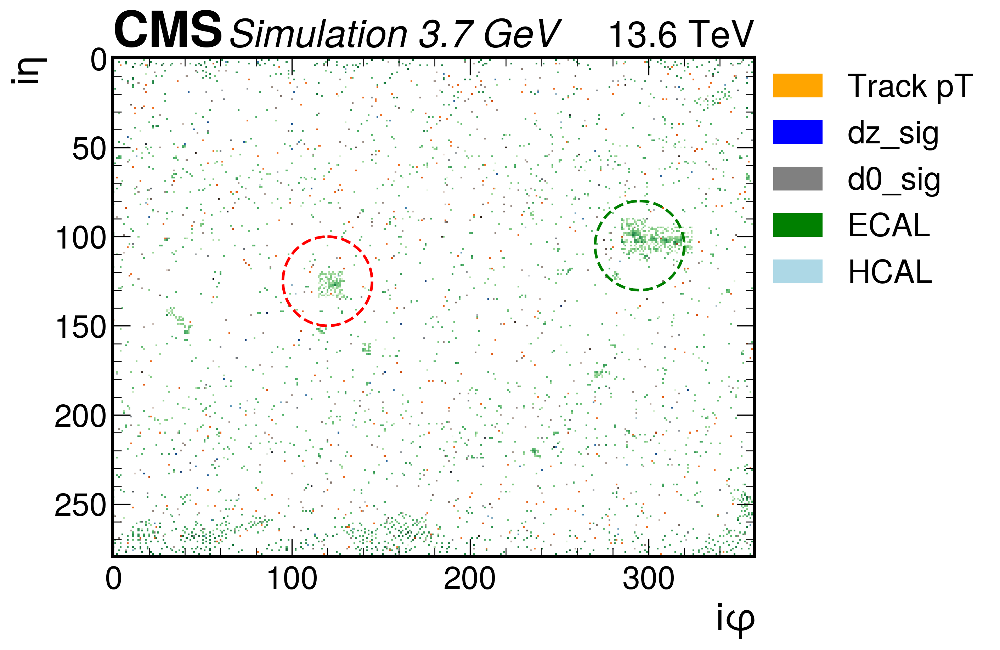

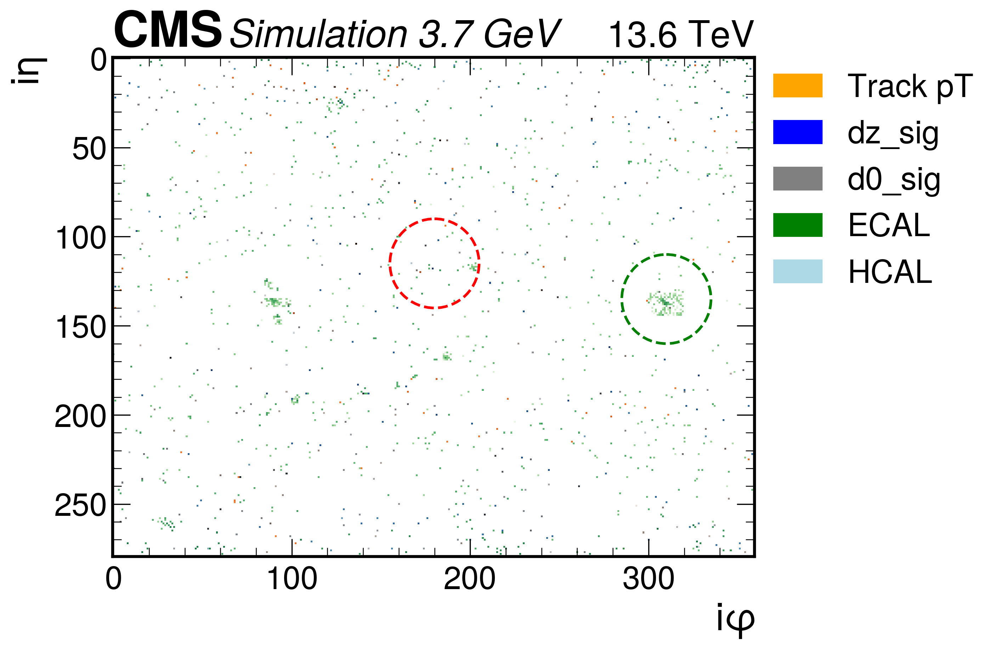

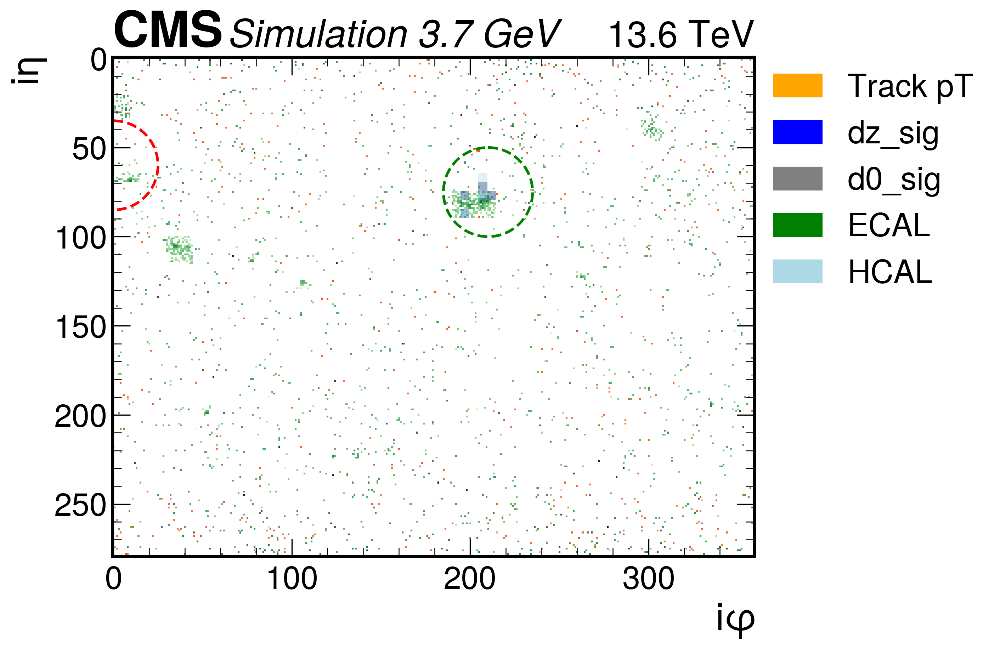

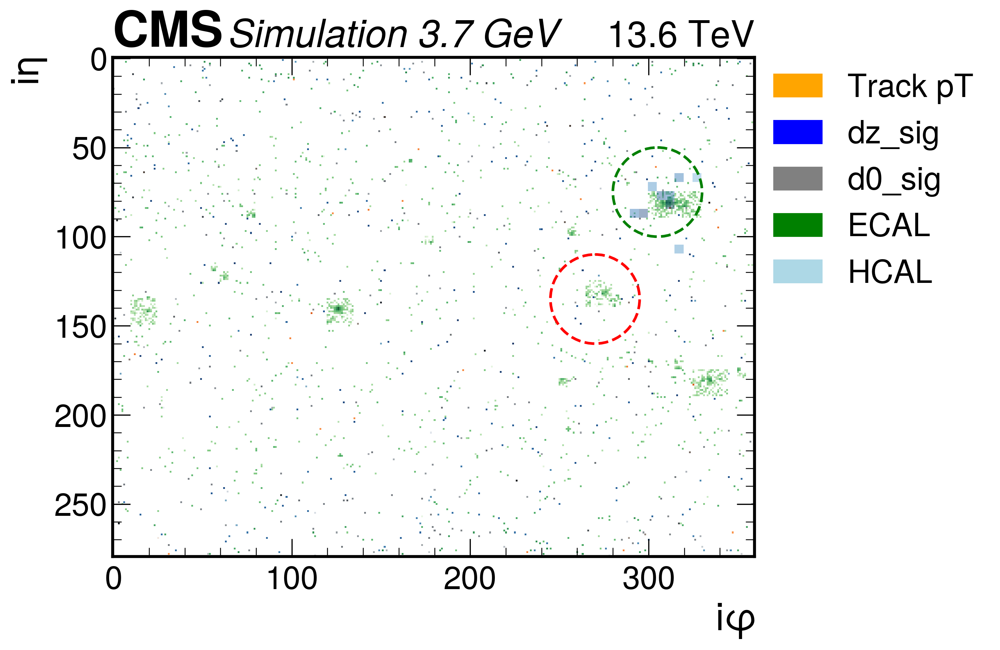

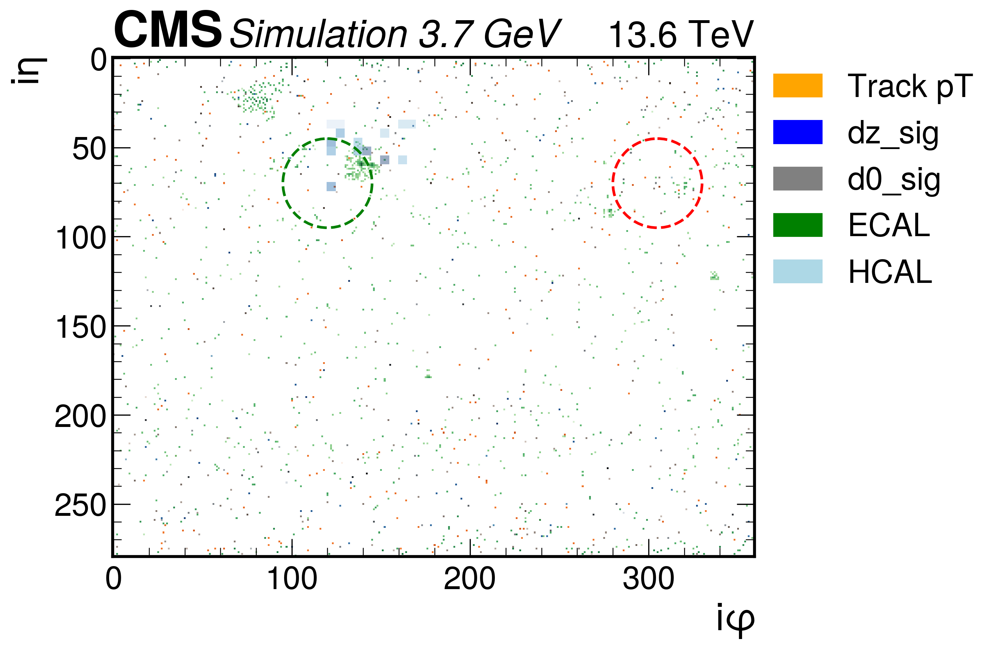

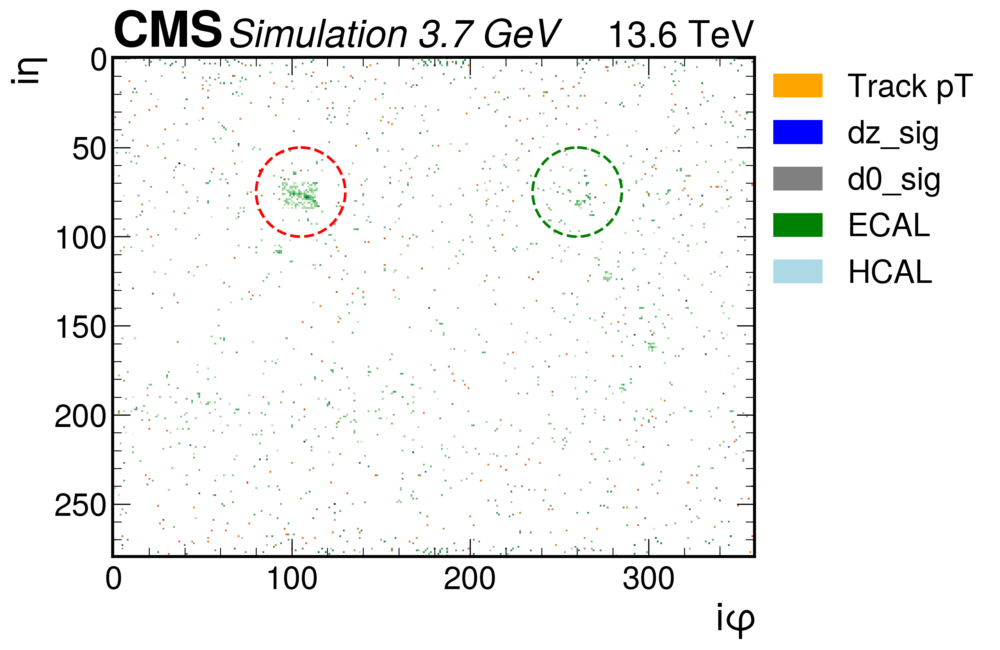

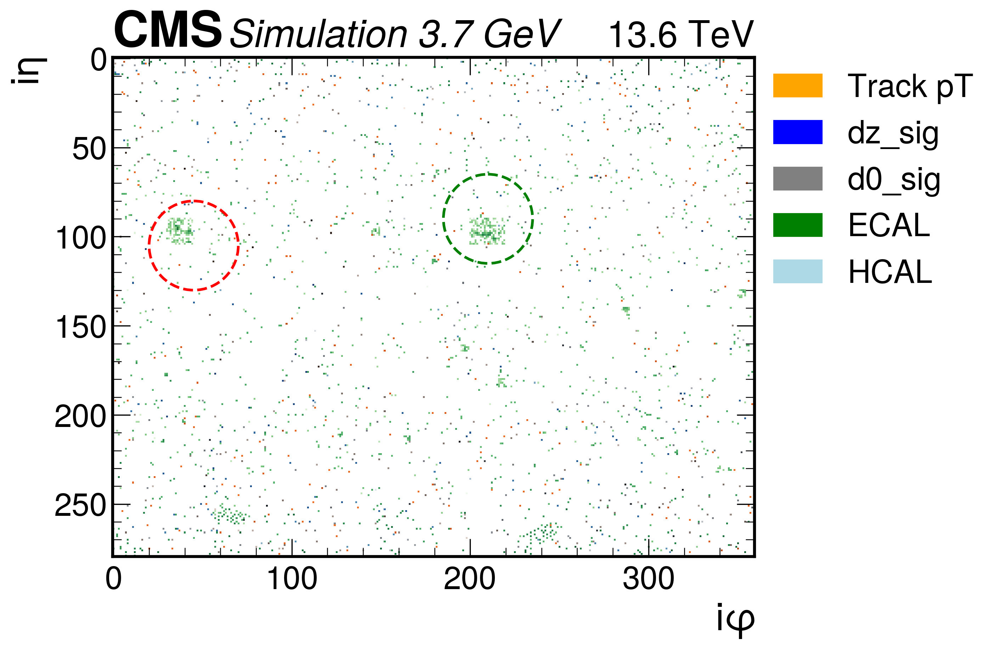

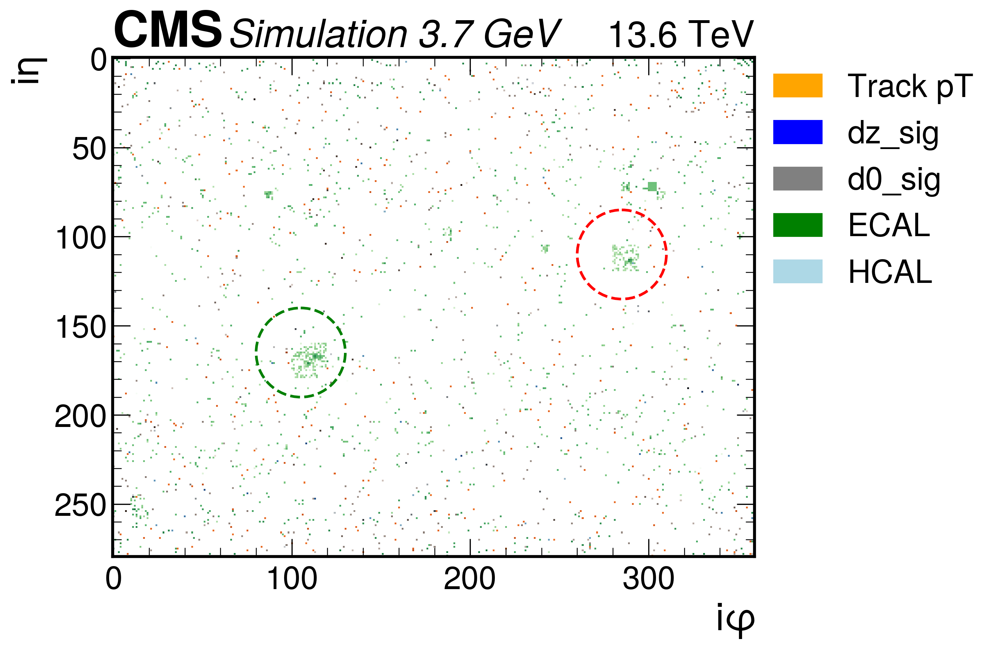

4_GeV
Opening: 4 GeV -> root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/HToAATo4Tau_hadronic_tauDecay_M4_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_4_GeV/260225_055101/0000/output_98.root


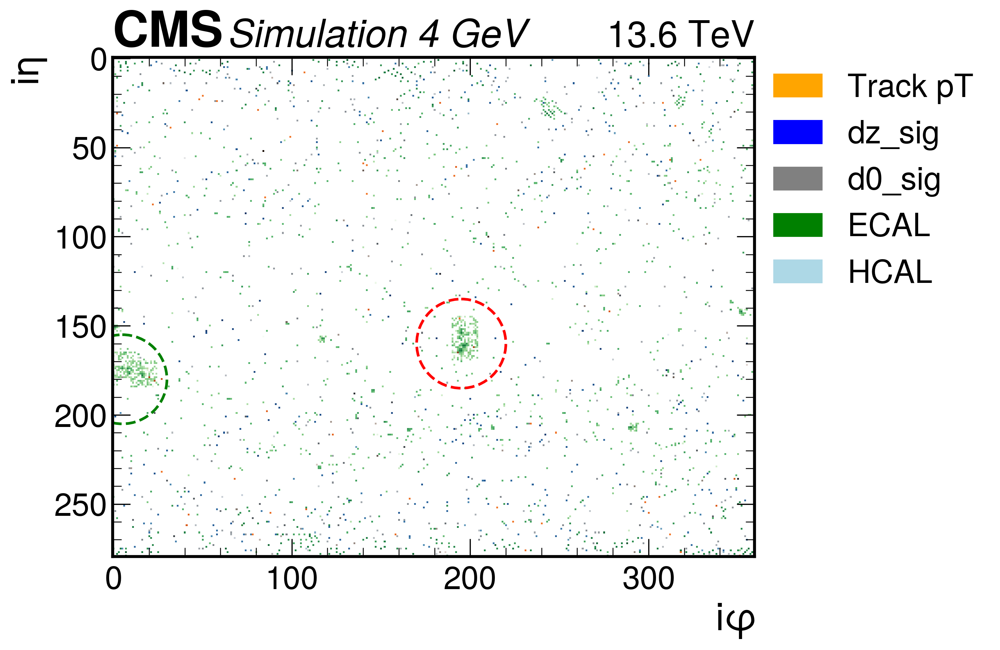

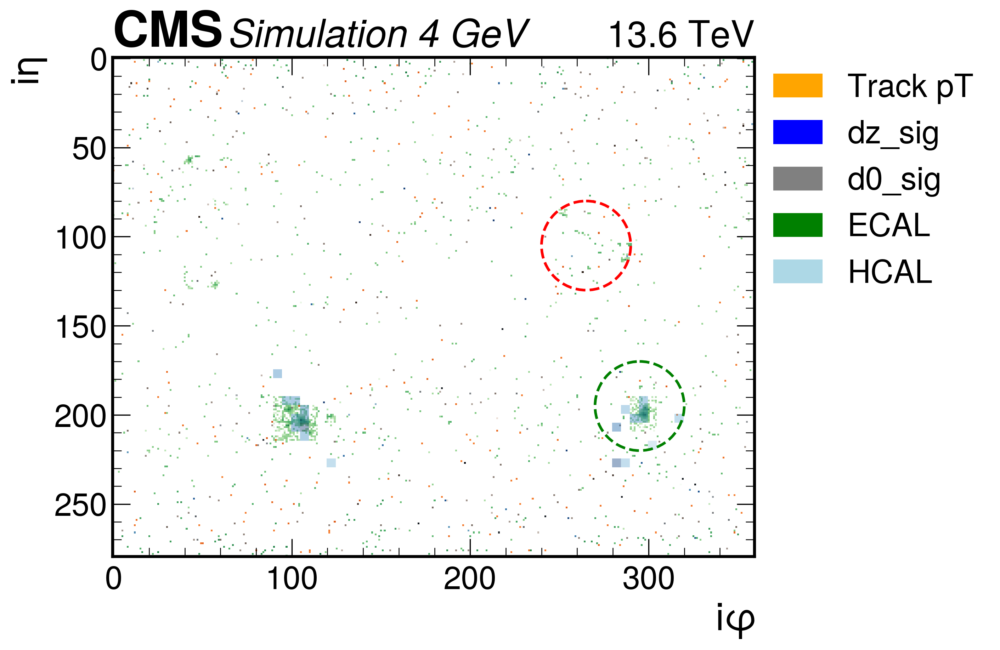

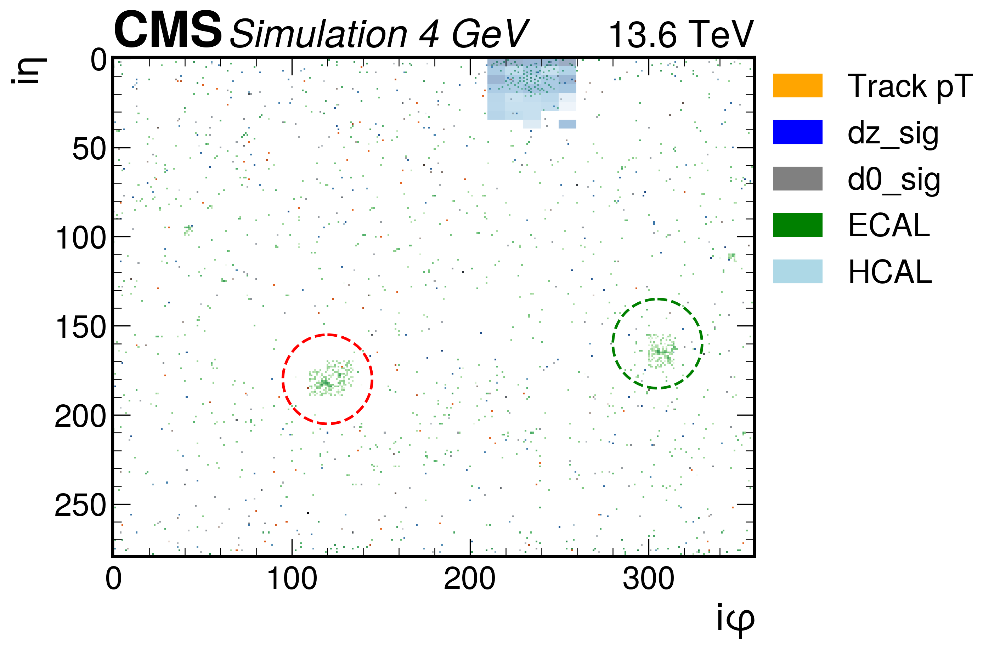

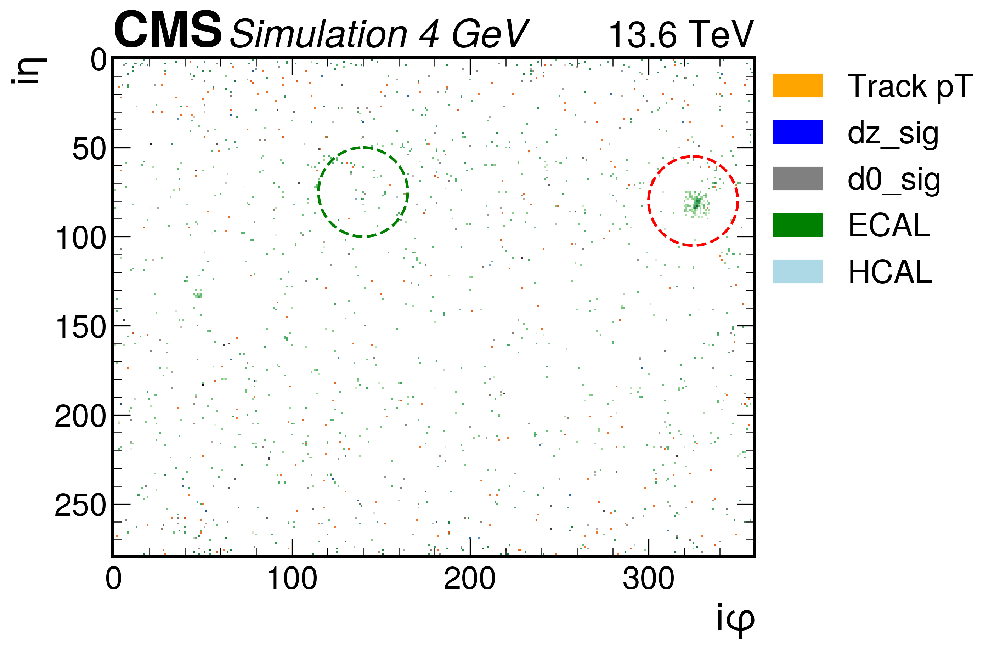

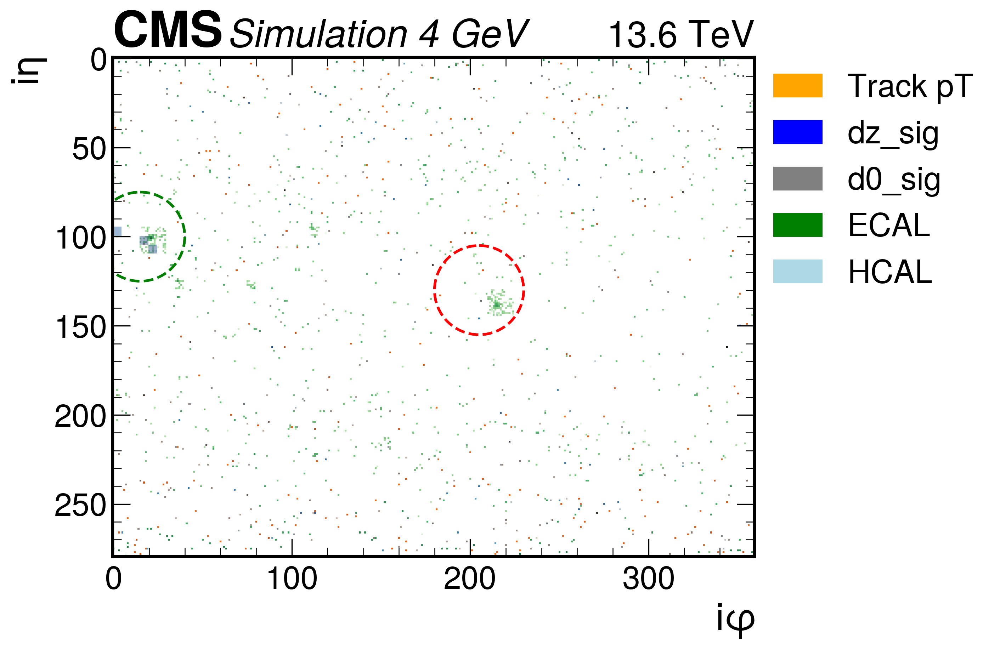

5_GeV
Opening: 5 GeV -> root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/HToAATo4Tau_hadronic_tauDecay_M5_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_5_GeV/260225_131350/0000/output_98.root


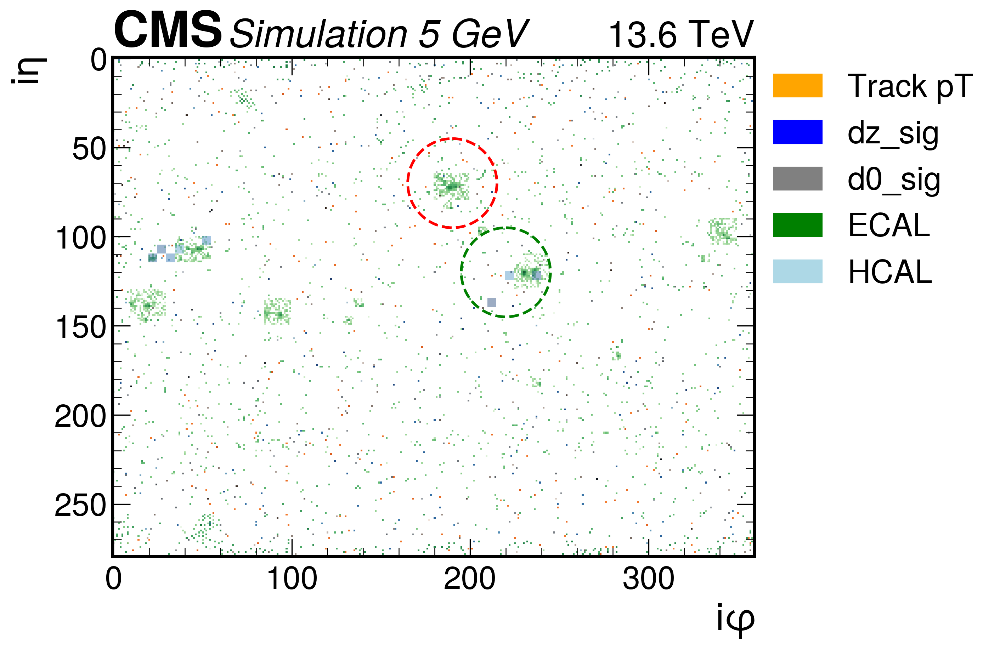

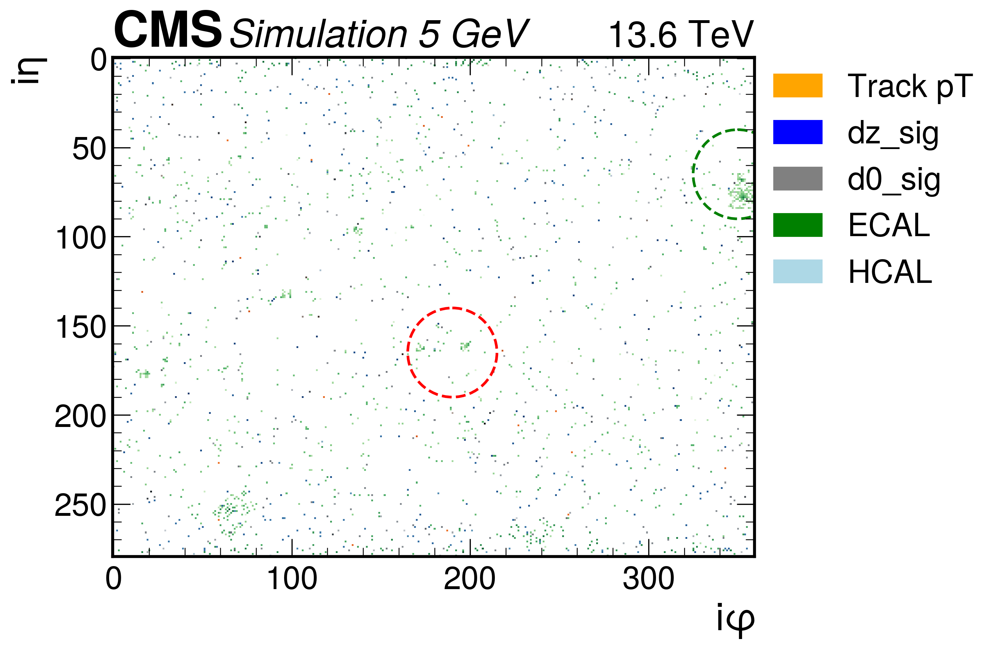

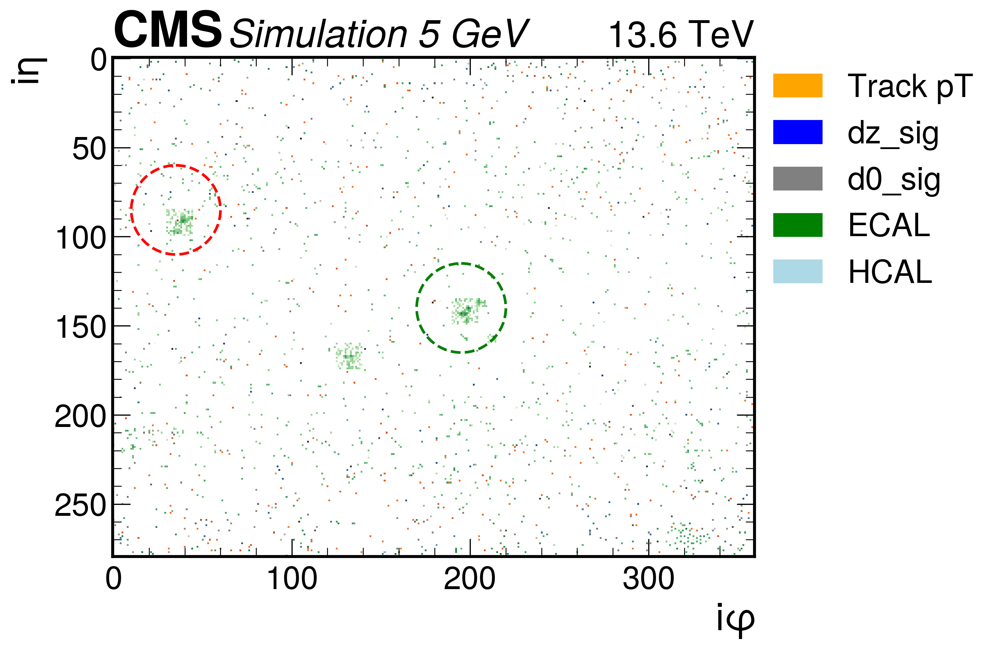

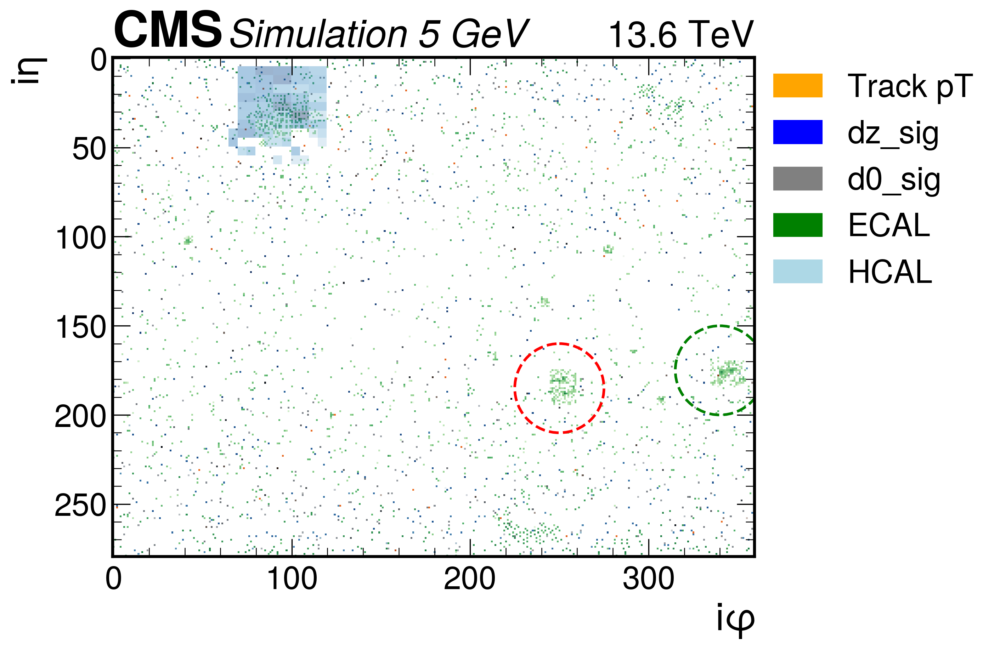

6_GeV
Opening: 6 GeV -> root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/HToAATo4Tau_hadronic_tauDecay_M6_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_6_GeV/260225_131414/0000/output_98.root


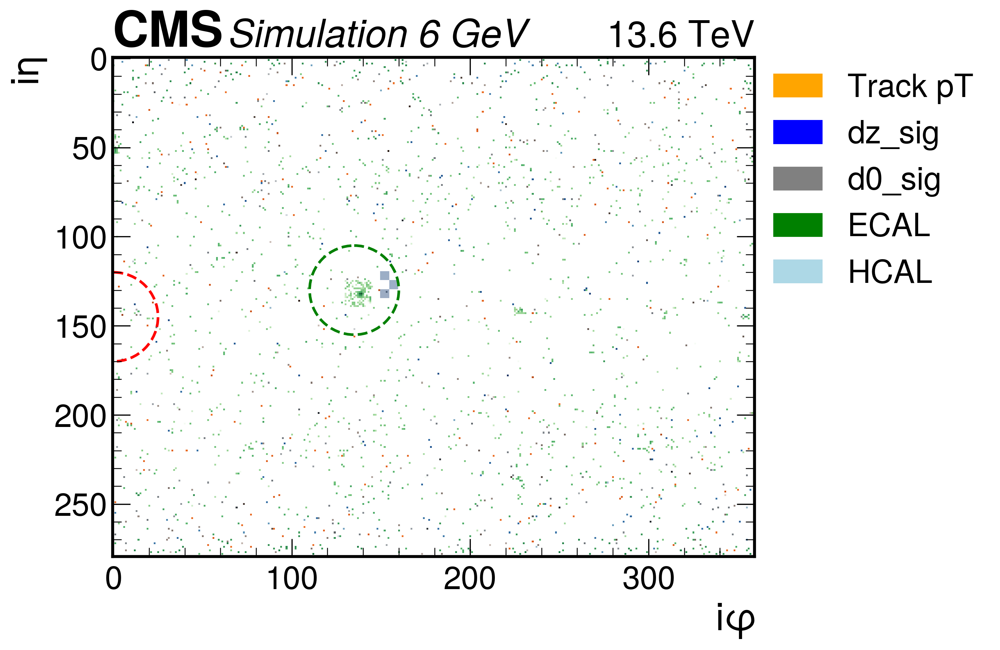

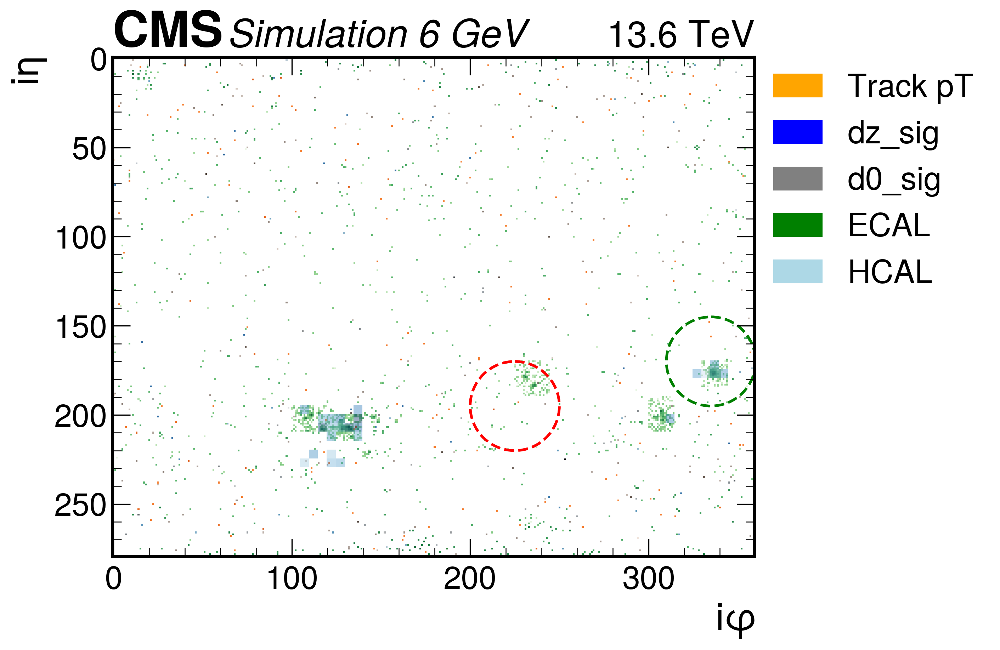

8_GeV
Opening: 8 GeV -> root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/HToAATo4Tau_hadronic_tauDecay_M8_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_8_GeV/260225_131435/0000/output_98.root


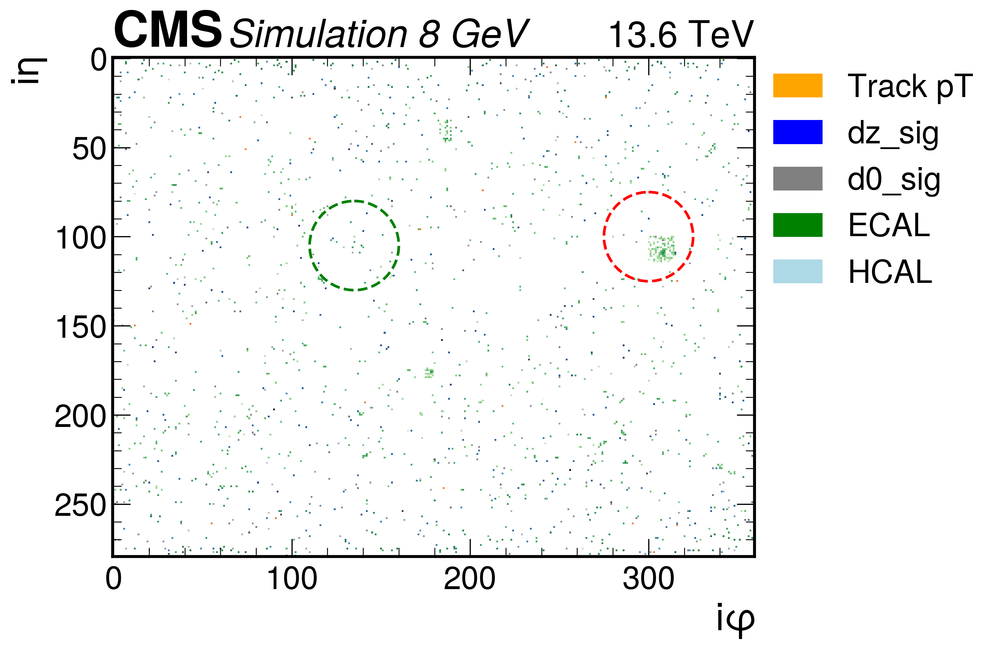

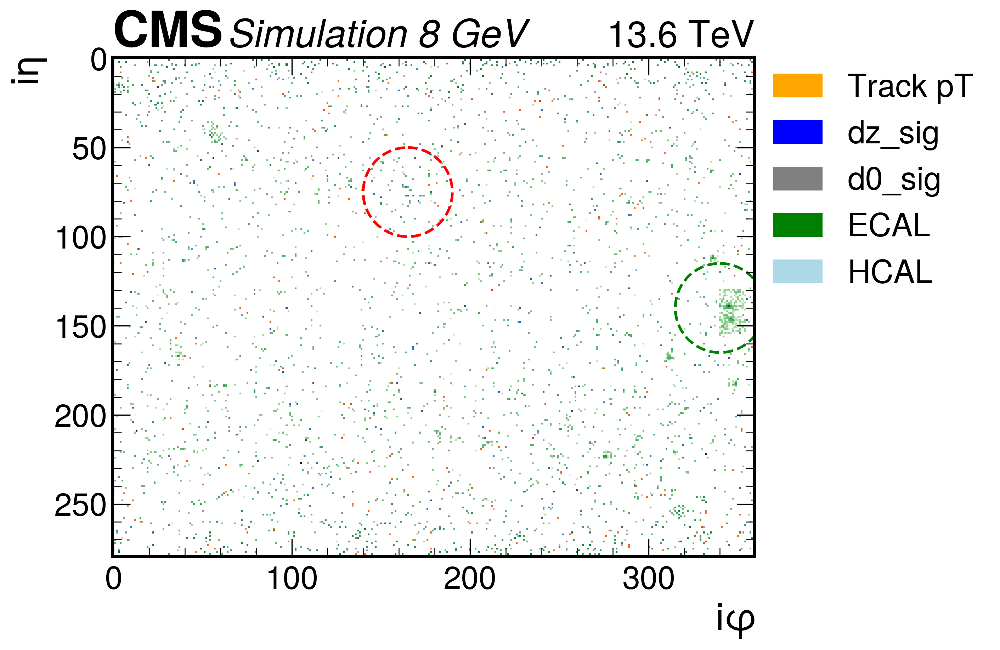

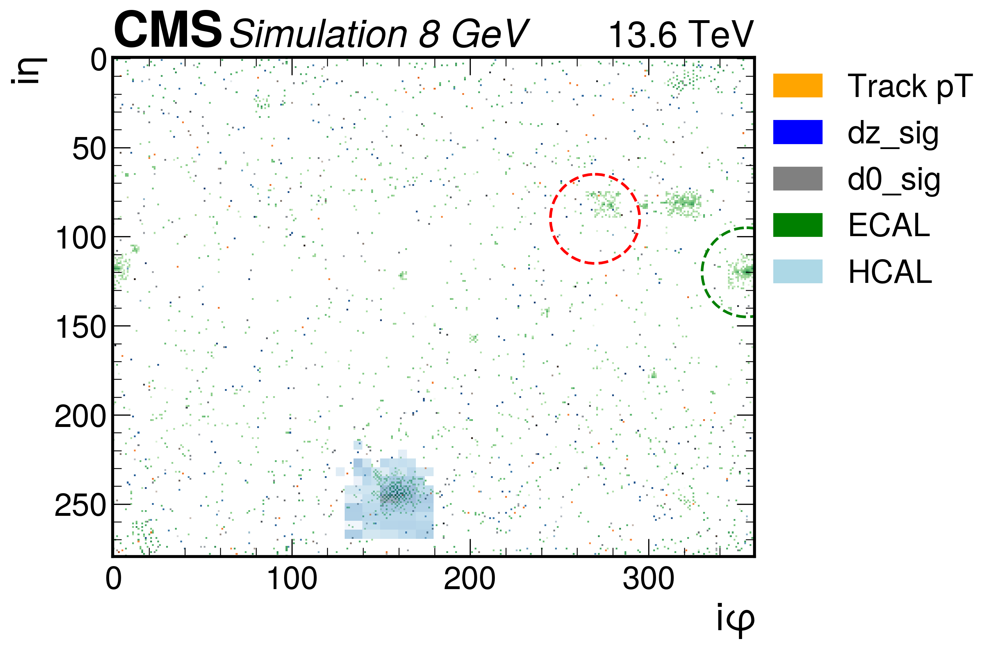

QCD
Opening: QCD -> root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/QCD_PT-15to7000_TuneCP5_13p6TeV_pythia8/MLAnalyzer_ntuples_using_miniAOD_QCD/260226_160954/0000/output_98.root


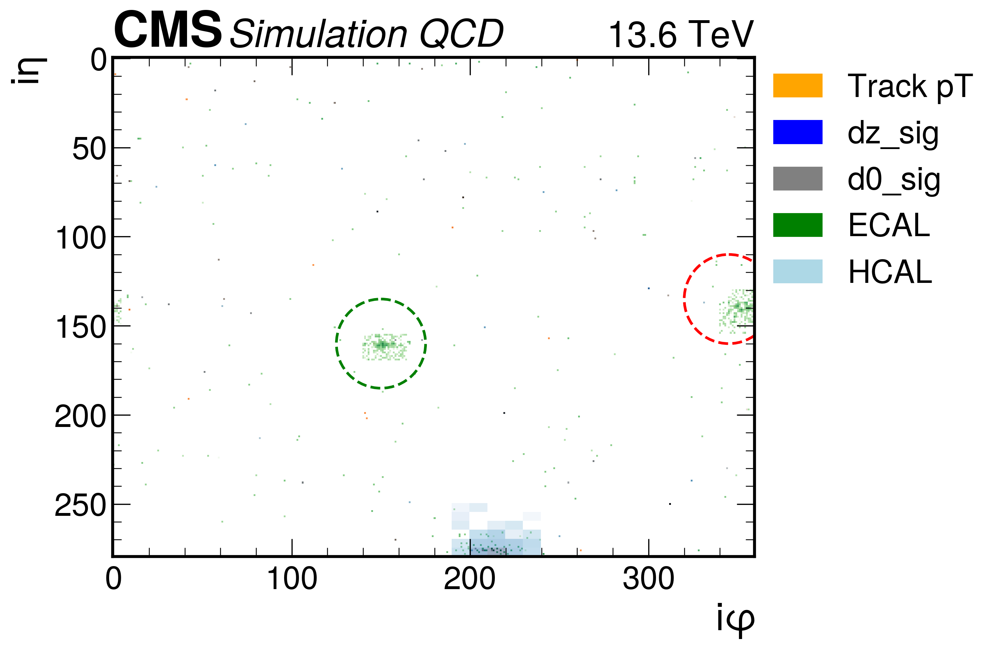

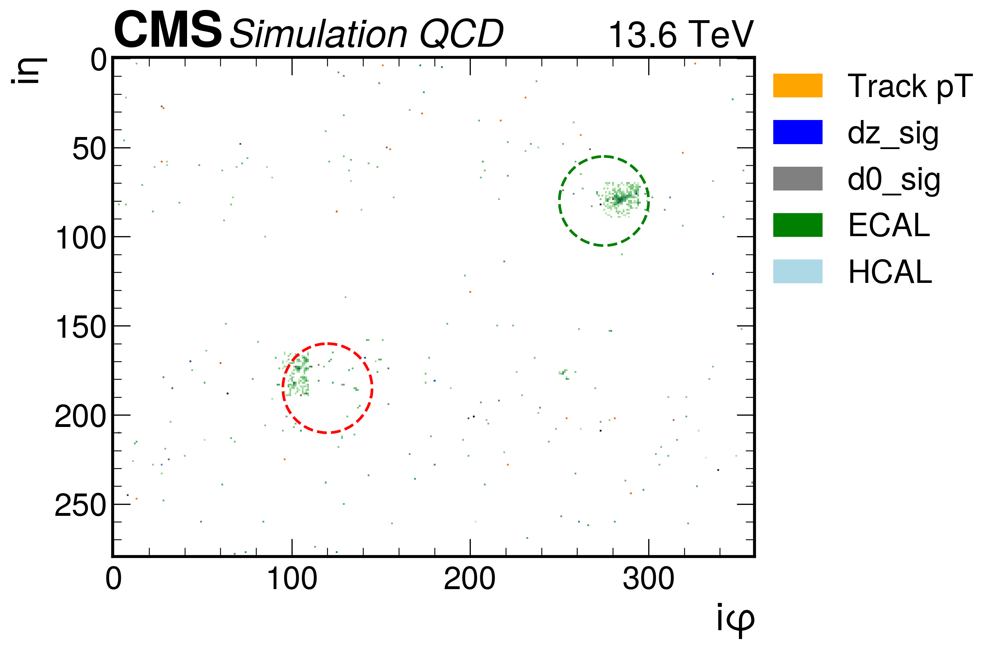

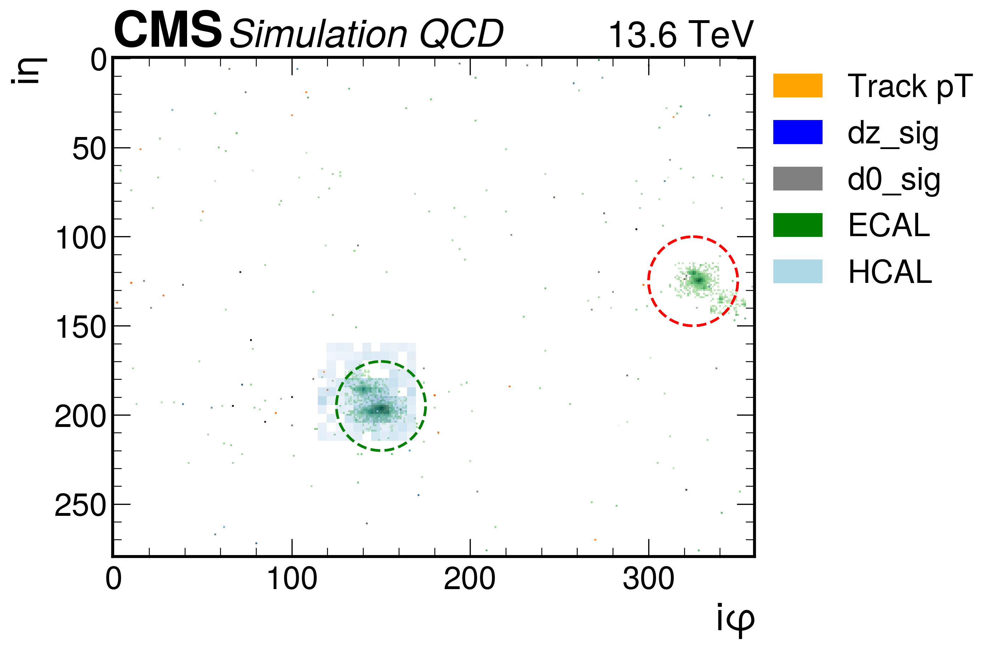

HTo2Tau
Opening: HTo2Tau -> root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/GluGluHToTauTau_M-125_TuneCP5_13p6TeV_powheg-pythia8/MLAnalyzer_ntuples_using_miniAOD_HTo2Tau/260226_164125/0000/output_98.root


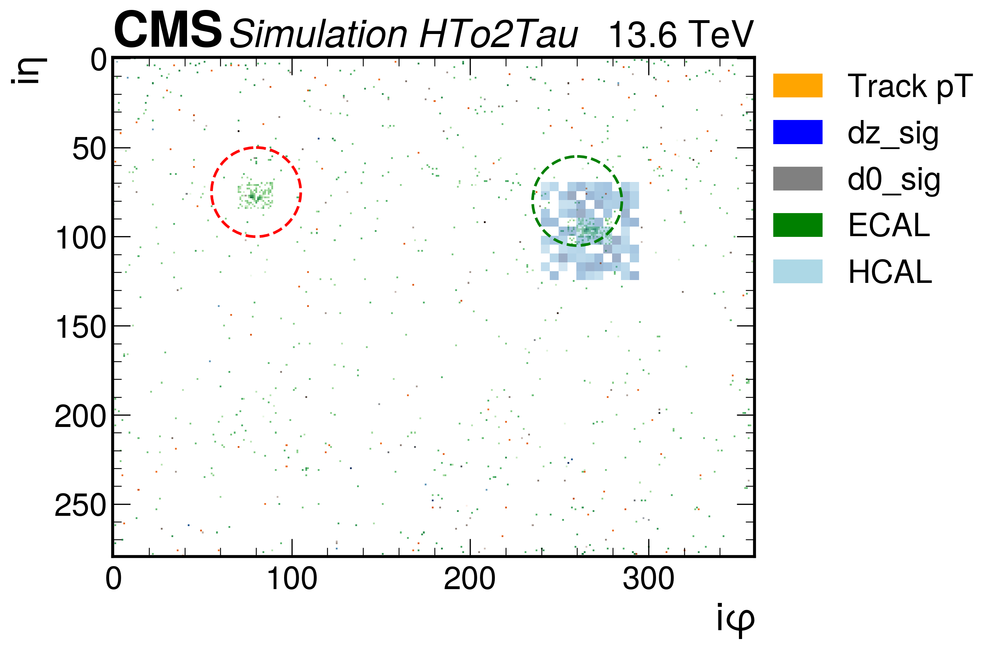

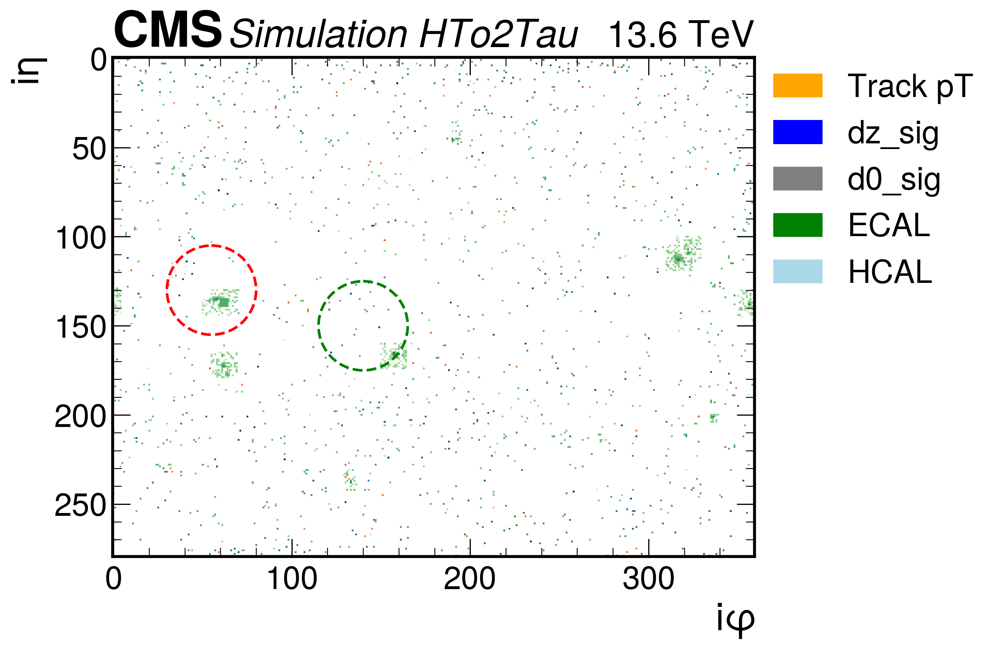

TTbar
Opening: TTbar -> root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/TT_TuneCP5_13p6TeV_powheg-pythia8/MLAnalyzer_ntuples_using_miniAOD_TTbar/260226_160423/0000/output_98.root


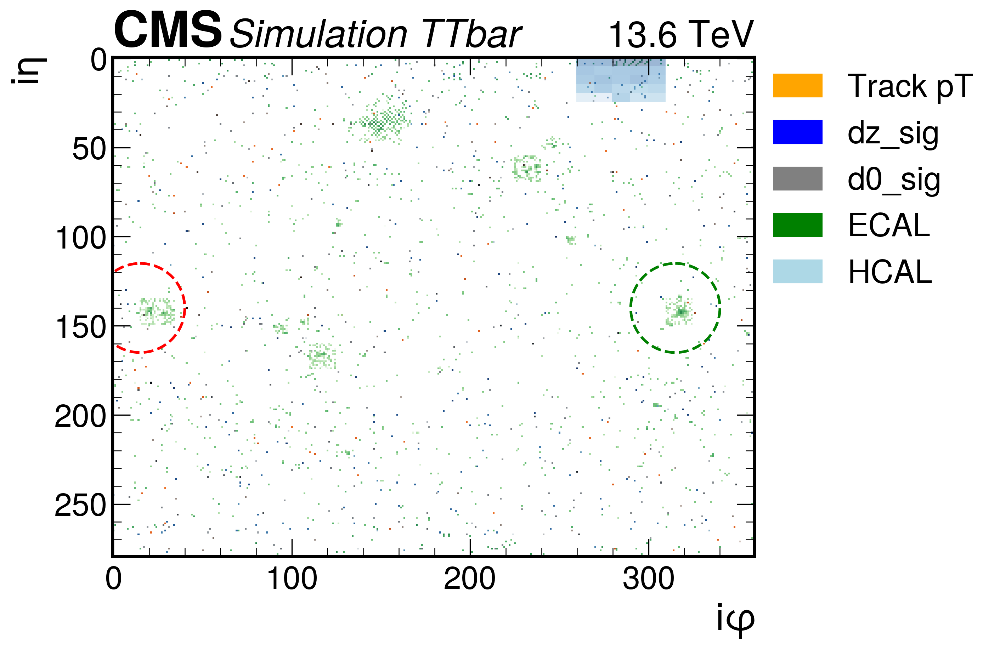

Wjets
Opening: Wjets -> root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/WtoLNu_2Jets_TuneCP5_13p6TeV_amcatnloFXFX_pythia8_v1/MLAnalyzer_ntuples_using_miniAOD_Wjets/260226_161832/0000/output_98.root


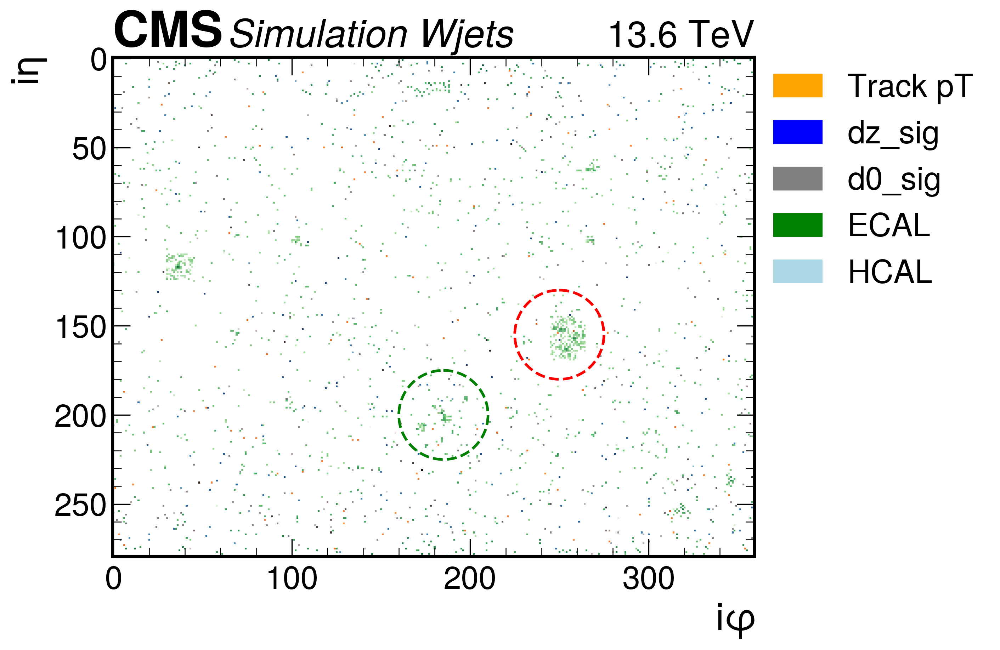

DYTo2L
Opening: DYTo2L -> root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/DYto2L_M-50_TuneCP5_13p6TeV_pythia8/MLAnalyzer_ntuples_using_miniAOD_DTTo2L/260226_170136/0000/output_98.root


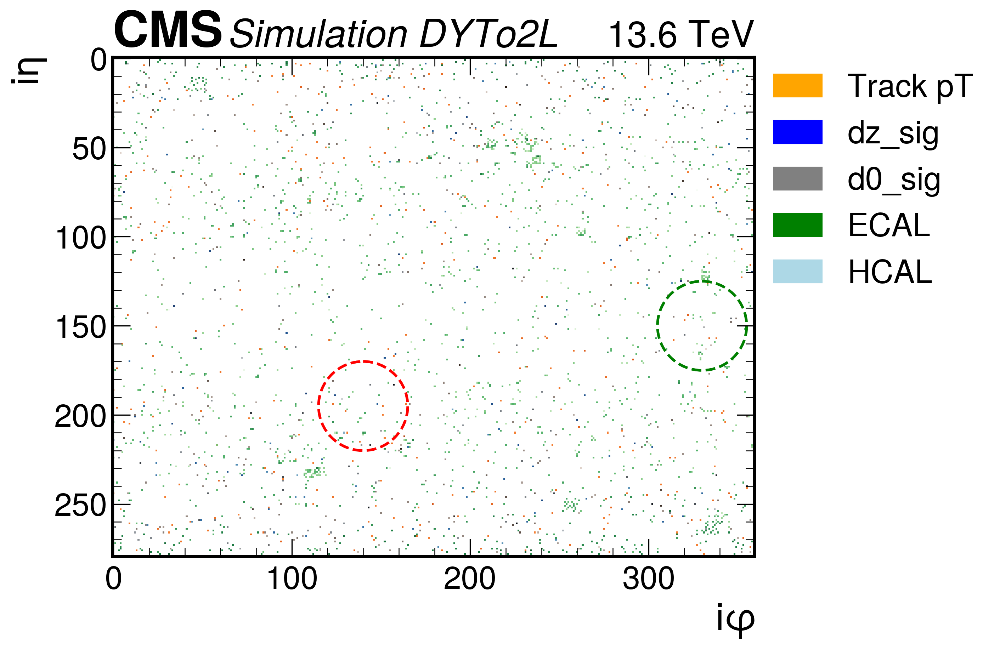

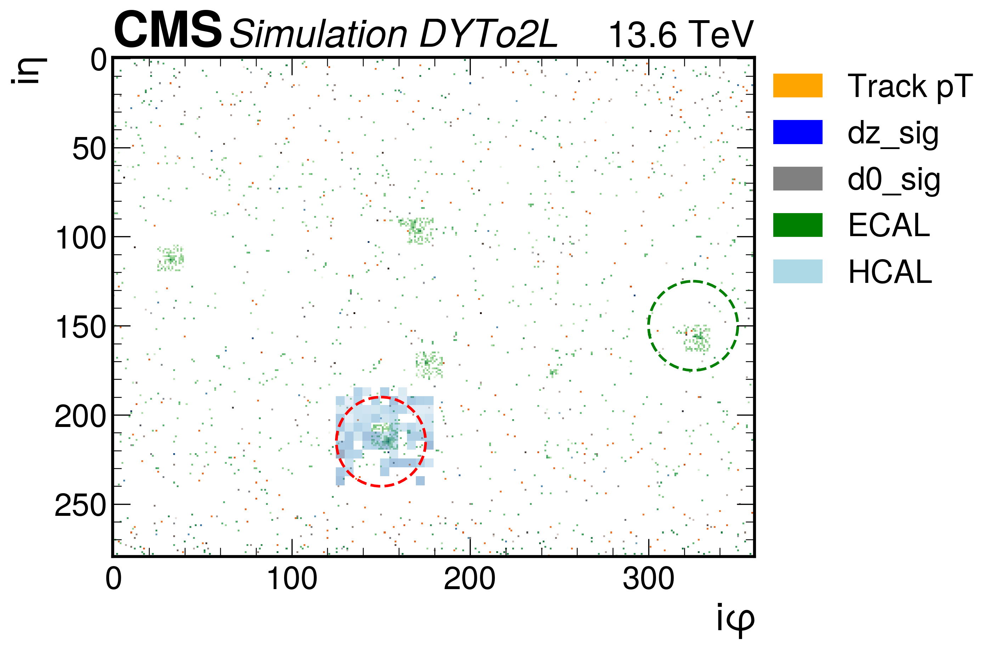

In [11]:
Samples = ['3.7 GeV', '4 GeV', '5 GeV', '6 GeV', '8 GeV',
           'QCD', 'HTo2Tau', 'TTbar', 'Wjets', 'DYTo2L']


def to_label(sample):
    """
    Convert mass-style labels like '3.7 GeV', '3p7 GeV', '5 Gev' -> '3p7_GeV'.
    Non-mass labels (QCD, TTbar, etc.) are returned unchanged.
    """
    parts = sample.split(' ')
    if len(parts) == 2 and parts[1].lower() == 'gev':
        value = parts[0].replace('.', 'p')
        return f"{value}_GeV"
    return sample

for sample in Samples:
    print(to_label(sample))
    # Path dictionary keyed by the SAME normalized labels to_label() produces
    # paths = {
    #     '3.7 GeV': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_June15_2026/HToAATo4Tau_hadronic_tauDecay_M3p7_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_June153p7_GeV/260615_191849/0000/output_98.root",
    #     '4 GeV':   "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_June15_2026/HToAATo4Tau_hadronic_tauDecay_M4_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_June154_GeV/260615_191944/0000/output_98.root",
    #     '5 GeV':   "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_June15_2026/HToAATo4Tau_hadronic_tauDecay_M5_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_June155_GeV/260615_192011/0000/output_98.root",
    #     '6 GeV':   "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_June15_2026/HToAATo4Tau_hadronic_tauDecay_M6_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_June156_GeV/260615_192027/0000/output_98.root",
    #     '8 GeV':   "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_June15_2026/HToAATo4Tau_hadronic_tauDecay_M8_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_June158_GeV/260615_192048/0000/output_98.root",
    #     'QCD':     "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_June15_2026/QCD_PT-15to7000_TuneCP5_13p6TeV_pythia8/MLAnalyzer_ntuples_using_miniAOD_June15QCD/260615_192135/0000/output_98.root",
    #     'HTo2Tau': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_June15_2026/GluGluHToTauTau_M-125_TuneCP5_13p6TeV_powheg-pythia8/MLAnalyzer_ntuples_using_miniAOD_June15HTo2Tau/260615_192212/0000/output_98.root",
    #     'TTbar':   "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_June15_2026/TT_TuneCP5_13p6TeV_powheg-pythia8/MLAnalyzer_ntuples_using_miniAOD_June15TTbar/260615_212045/0000/output_98.root",
    #     'Wjets':   "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_June15_2026/WtoLNu_2Jets_TuneCP5_13p6TeV_amcatnloFXFX_pythia8_v1/MLAnalyzer_ntuples_using_miniAOD_June15Wjets/260615_192155/0000/output_98.root",
    #     'DYTo2L':  "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_June15_2026/DYto2L_M-50_TuneCP5_13p6TeV_pythia8/MLAnalyzer_ntuples_using_miniAOD_June15DTTo2L/260615_192230/0000/output_98.root",
    # }.get(sample, None)


    paths = {
        '3.7 GeV': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/HToAATo4Tau_hadronic_tauDecay_M3p7_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_3p7_GeV/260225_052605/0000/output_98.root"
        ,'4 GeV': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/HToAATo4Tau_hadronic_tauDecay_M4_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_4_GeV/260225_055101/0000/output_98.root"
        ,'5 GeV': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/HToAATo4Tau_hadronic_tauDecay_M5_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_5_GeV/260225_131350/0000/output_98.root"
        ,'6 GeV': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/HToAATo4Tau_hadronic_tauDecay_M6_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_6_GeV/260225_131414/0000/output_98.root"
        ,'8 GeV': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/HToAATo4Tau_hadronic_tauDecay_M8_Run3_2023/MLAnalyzer_ntuples_using_miniAOD_8_GeV/260225_131435/0000/output_98.root"
        ,'QCD': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/QCD_PT-15to7000_TuneCP5_13p6TeV_pythia8/MLAnalyzer_ntuples_using_miniAOD_QCD/260226_160954/0000/output_98.root"
        ,'HTo2Tau': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/GluGluHToTauTau_M-125_TuneCP5_13p6TeV_powheg-pythia8/MLAnalyzer_ntuples_using_miniAOD_HTo2Tau/260226_164125/0000/output_98.root"
        ,'TTbar': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/TT_TuneCP5_13p6TeV_powheg-pythia8/MLAnalyzer_ntuples_using_miniAOD_TTbar/260226_160423/0000/output_98.root"
        ,'Wjets': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/WtoLNu_2Jets_TuneCP5_13p6TeV_amcatnloFXFX_pythia8_v1/MLAnalyzer_ntuples_using_miniAOD_Wjets/260226_161832/0000/output_98.root"
        ,'DYTo2L': "root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_Signal_Background_Feb24_2026/DYto2L_M-50_TuneCP5_13p6TeV_pythia8/MLAnalyzer_ntuples_using_miniAOD_DTTo2L/260226_170136/0000/output_98.root"
        }.get(sample, None)
    
    if paths is None:
        raise KeyError(f"No path found for sample='{sample}'. Check dict keys match Samples list exactly.")

    print(f"Opening: {sample} -> {paths}")
    file = uproot.open(paths)
    RHTree = file["fevt/RHTree"]
    # branches = RHTree.arrays()
    branches = RHTree.arrays(entry_start=10, entry_stop=20)
    for eve in range(10):
        make_img_eve_full_circle_and_cropped_circle(eve, sample)
        
        

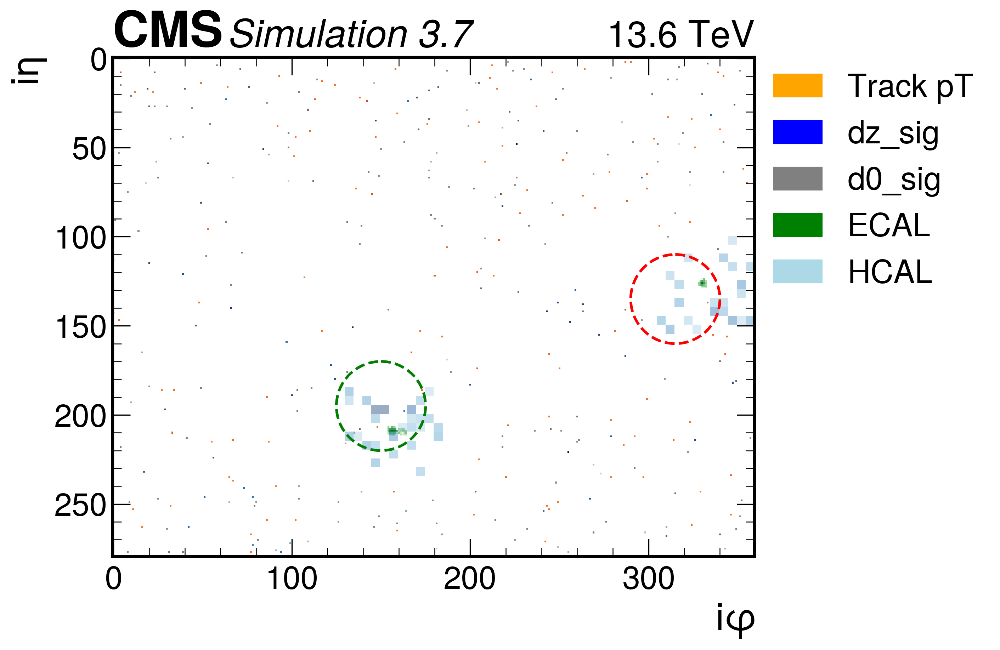

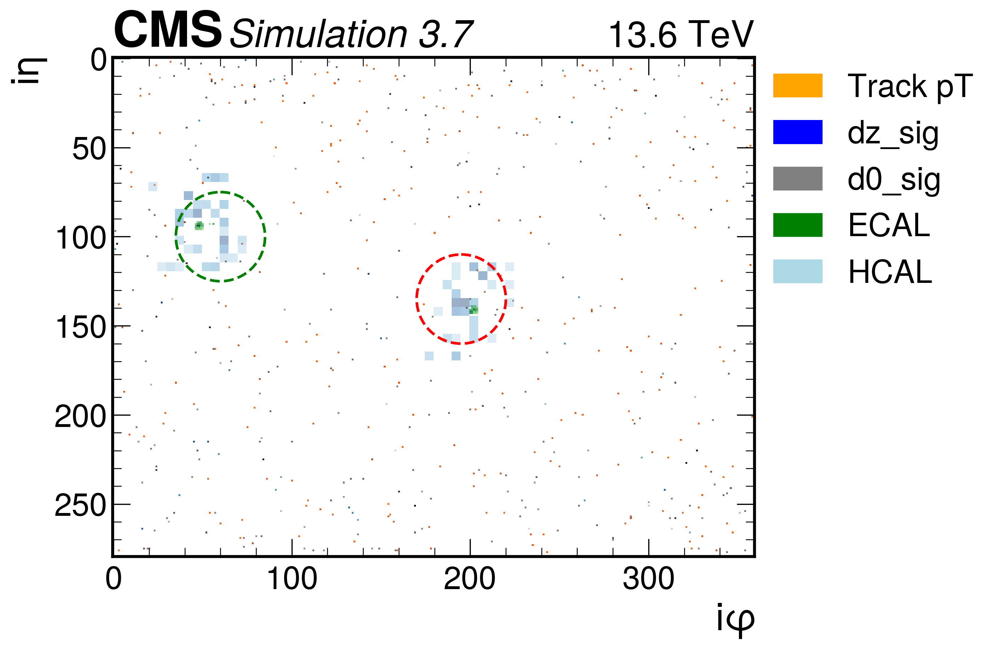

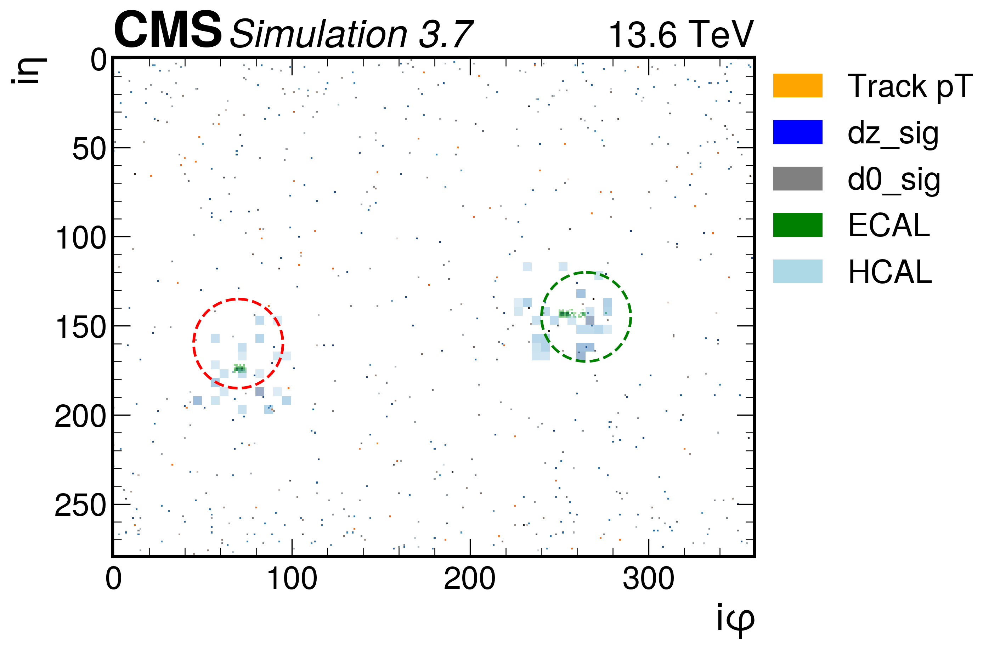

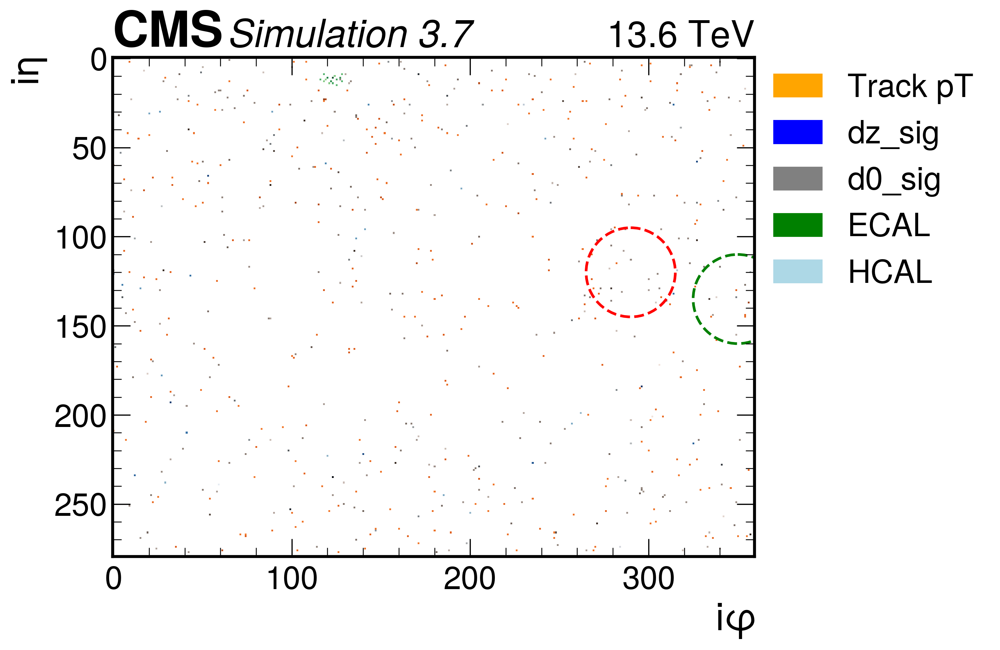

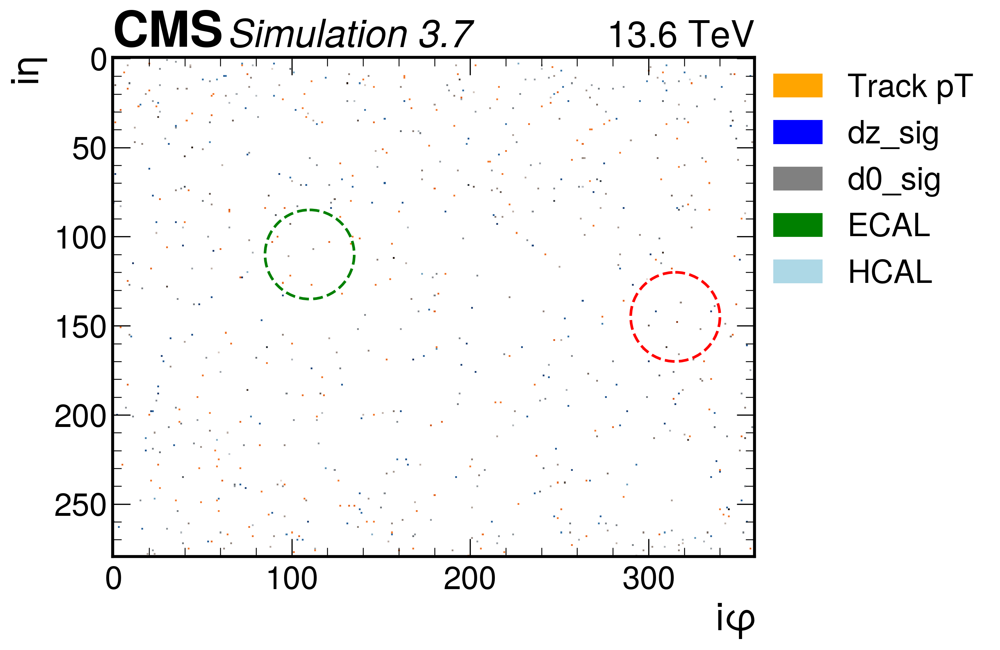

...

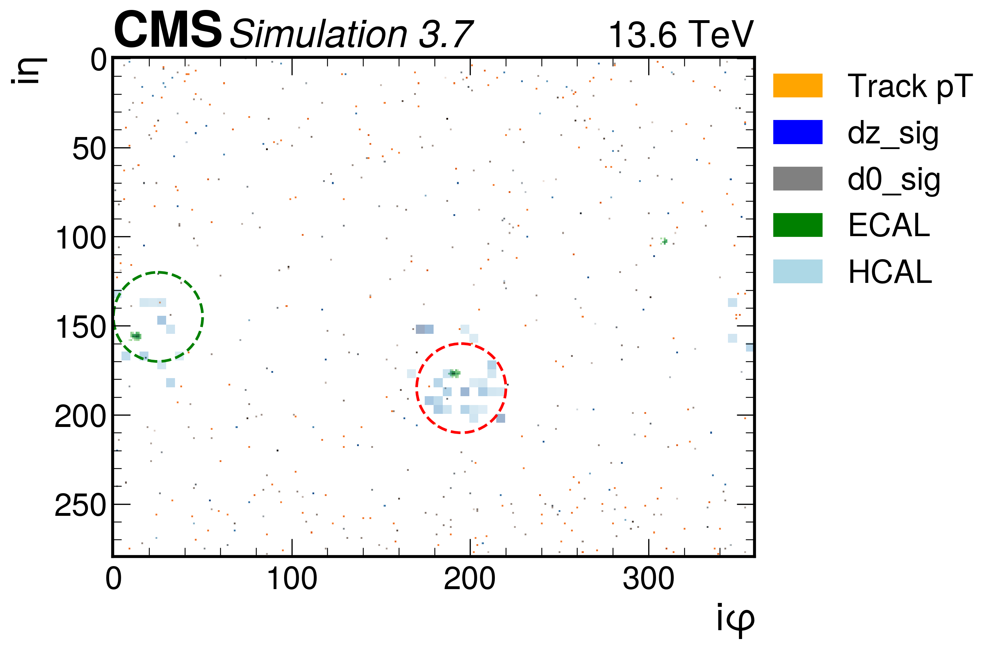

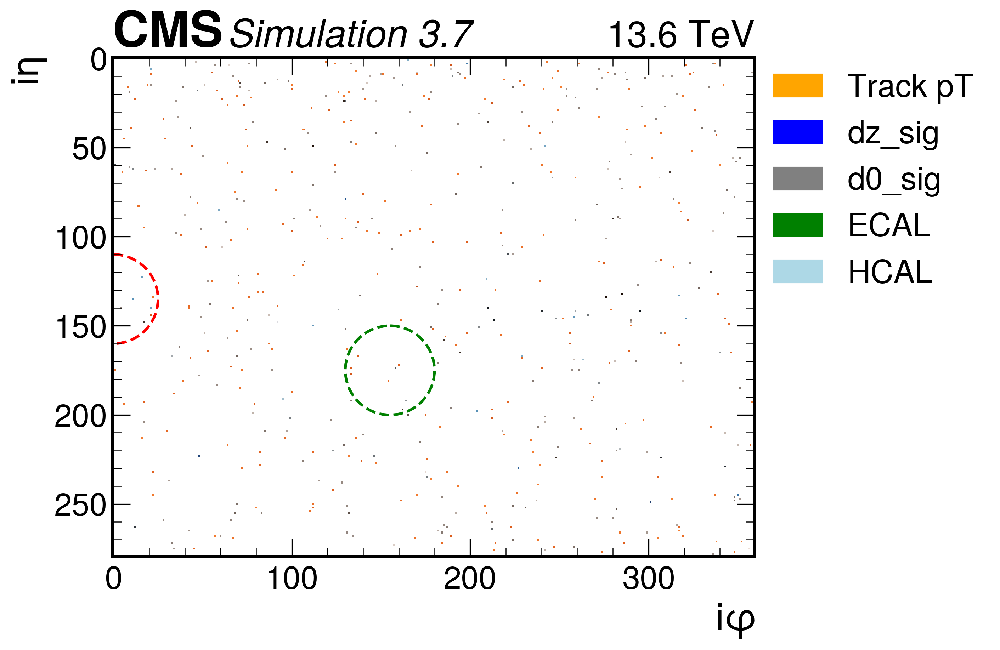

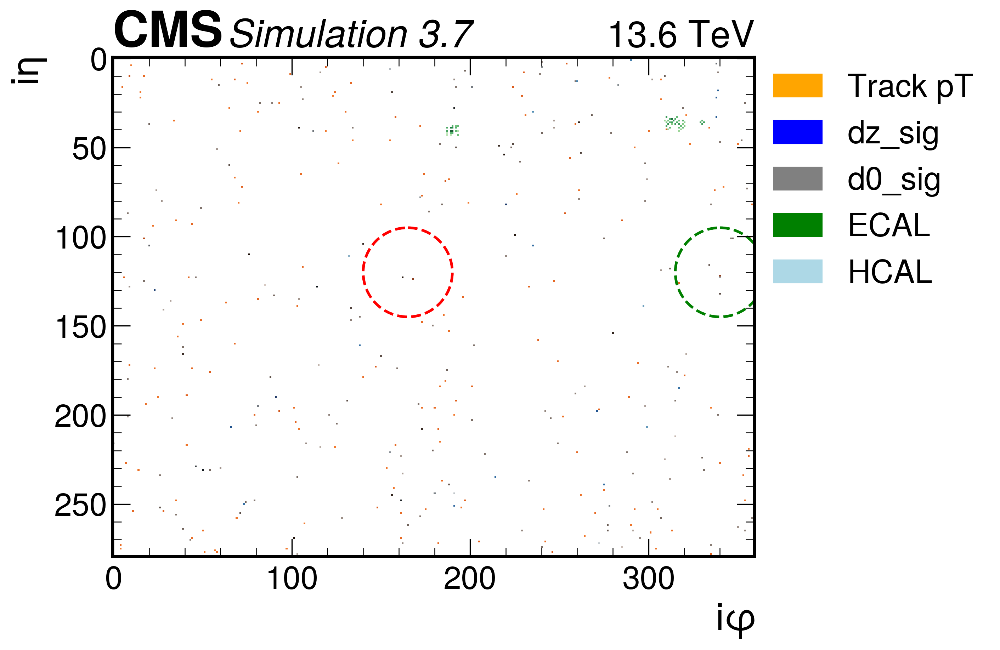

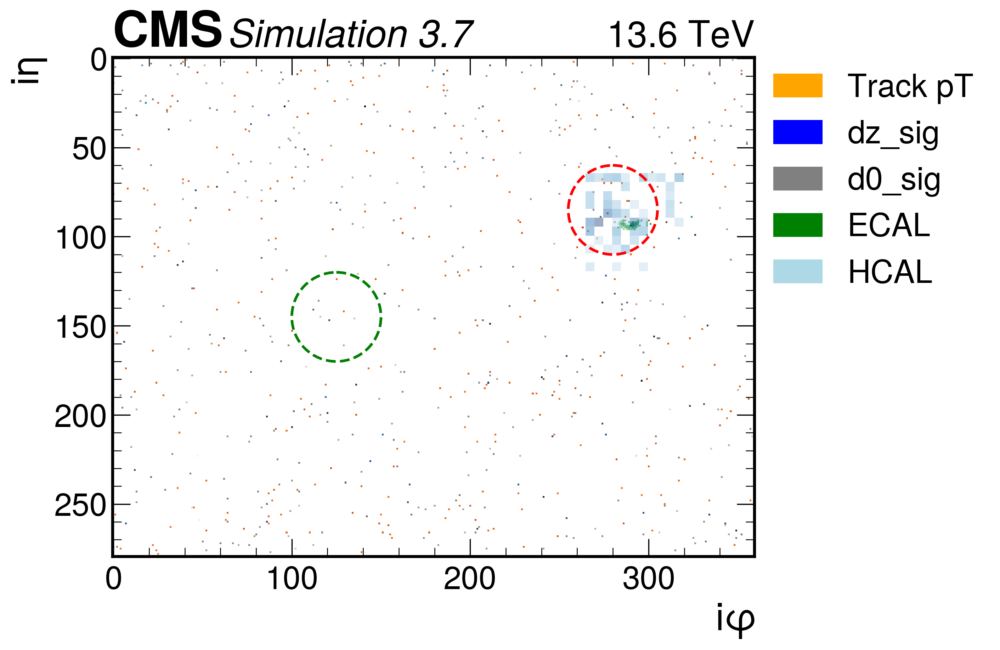

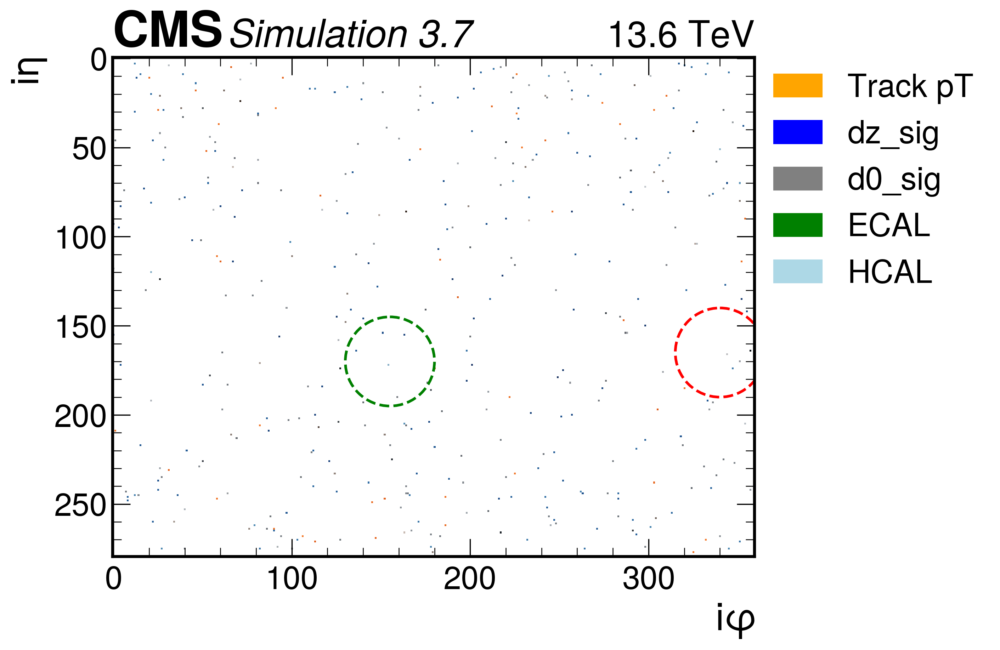

In [ ]:



paths = "../analysis_run3/analyzer_from_Ruchi/data_miniAOD/CMSSW_13_0_14/src/MLAnalyzerRun3/Tau_MINIAOD_22Sep2023_numEvent100.root"
file = uproot.open(paths)
RHTree = file["fevt/RHTree"]
# branches = RHTree.arrays()
branches = RHTree.arrays(entry_start=0, entry_stop=40)
for eve in range(40):
    make_img_eve_full_circle_and_cropped_circle(eve, 3.7)

In [18]:
branches

<Array [] type='0 * {hltAccept_doubleTau: int32, hltAccept_pfmet: int32, hl...'>